In [1]:
import numpy as np
from pathlib import Path
from collections import Counter

# =========================
# Settings you may edit
# =========================
EIDS = range(1, 101)
TRAJ_PATTERN = "traj_E{eid:03d}.lammpstrj"

TYPE_CORE_AL = 4
TYPE_O = {2, 3}

CN_RADIUS = 2.325      # Å (same as your CN cutoff)
FS_TO_PS = 0.001       # timestep=1 fs -> 0.001 ps
MIN_FRAMES = 5         # require O appears as 3-of-3 common neighbour at least this many frames (robust)
EARLY_ONLY_PS = None   # e.g. set 3.0 if you only want to count events within first 3 ps; None = anywhere in 10 ps

OUTCSV = "jumpback_summary.csv"


# =========================
# Helpers
# =========================
def minimum_image(dr, L):
    return dr - L * np.round(dr / L)

def mic_distance(a, b, L):
    return float(np.linalg.norm(minimum_image(b - a, L)))

def iter_frames_lammpstrj(file):
    """
    Reads LAMMPS dump with:
      ITEM: TIMESTEP
      ITEM: NUMBER OF ATOMS
      ITEM: BOX BOUNDS ...
      ITEM: ATOMS id type q x y z
    Yields (ts, L, atoms) where atoms columns: id, type, x, y, z
    """
    file = Path(file)
    with file.open("r") as f:
        while True:
            line = f.readline()
            if not line:
                break
            if not line.startswith("ITEM: TIMESTEP"):
                continue

            ts = int(f.readline().strip())
            _ = f.readline()
            n = int(f.readline().strip())

            _ = f.readline()  # BOX BOUNDS
            bounds = []
            for _ in range(3):
                lo, hi, *_ = f.readline().split()
                bounds.append((float(lo), float(hi)))
            bounds = np.array(bounds, dtype=float)
            L = bounds[:, 1] - bounds[:, 0]

            atoms_header = f.readline().strip()  # ITEM: ATOMS ...
            cols = atoms_header.split()[2:]
            idx = {c: i for i, c in enumerate(cols)}
            for c in ["id", "type", "x", "y", "z"]:
                if c not in idx:
                    raise ValueError(f"{file.name}: missing column {c} in {cols}")

            atoms = np.empty((n, 5), dtype=float)
            for i in range(n):
                parts = f.readline().split()
                atoms[i, 0] = float(parts[idx["id"]])
                atoms[i, 1] = float(parts[idx["type"]])
                atoms[i, 2] = float(parts[idx["x"]])
                atoms[i, 3] = float(parts[idx["y"]])
                atoms[i, 4] = float(parts[idx["z"]])

            yield ts, L, atoms

def build_map(atoms):
    """id -> (type, pos)"""
    m = {}
    for row in atoms:
        aid = int(round(row[0]))
        atype = int(round(row[1]))
        pos = row[2:5].astype(float)
        m[aid] = (atype, pos)
    return m

def o_neighbors_within(al_pos, O_items, L, rcut):
    s = set()
    for oid, opos in O_items:
        if mic_distance(al_pos, opos, L) <= rcut:
            s.add(oid)
    return s


# =========================
# Core detection per event
# =========================
def detect_jumpback_for_traj(traj_file):
    """
    Returns dict with:
      core_ids, best_oid, first_time_ps, frames_count, has_jumpback
    """
    frames = [(ts, L, atoms) for ts, L, atoms in iter_frames_lammpstrj(traj_file)]
    if not frames:
        return {"has_jumpback": False, "reason": "empty_traj"}

    # core ids from first frame
    ts0, L0, atoms0 = frames[0]
    m0 = build_map(atoms0)
    core_ids = sorted([aid for aid, (tp, _) in m0.items() if tp == TYPE_CORE_AL])
    if len(core_ids) != 3:
        return {"has_jumpback": False, "reason": f"core_count={len(core_ids)}", "core_ids": core_ids}

    # track: for each oid, list of timesteps when it is common-to-3
    times_by_oid = {}
    count_by_oid = Counter()

    for ts, L, atoms in frames:
        t_ps = ts * FS_TO_PS
        if EARLY_ONLY_PS is not None and t_ps > EARLY_ONLY_PS:
            continue

        m = build_map(atoms)
        O_items = [(aid, pos) for aid, (tp, pos) in m.items() if tp in TYPE_O]
        core_pos = [m[cid][1] for cid in core_ids]

        neigh = [o_neighbors_within(core_pos[i], O_items, L, CN_RADIUS) for i in range(3)]
        common3 = neigh[0] & neigh[1] & neigh[2]

        for oid in common3:
            count_by_oid[oid] += 1
            times_by_oid.setdefault(oid, []).append(t_ps)

    if not count_by_oid:
        return {"has_jumpback": False, "core_ids": core_ids, "reason": "no_common3"}

    # choose the most frequent oid
    best_oid, best_cnt = count_by_oid.most_common(1)[0]
    if best_cnt < MIN_FRAMES:
        return {
            "has_jumpback": False,
            "core_ids": core_ids,
            "reason": f"below_threshold({best_cnt}<{MIN_FRAMES})",
            "best_oid": best_oid,
            "frames_count": best_cnt,
        }

    first_time = min(times_by_oid[best_oid]) if best_oid in times_by_oid else None
    return {
        "has_jumpback": True,
        "core_ids": core_ids,
        "best_oid": best_oid,
        "first_time_ps": first_time,
        "frames_count": best_cnt,
        "reason": "ok"
    }


def main():
    rows = []
    n_found = 0
    n_total = 0

    for eid in EIDS:
        traj = Path(TRAJ_PATTERN.format(eid=eid))
        if not traj.exists():
            rows.append({
                "eid": eid,
                "status": "missing_file",
                "has_jumpback": False,
                "best_oid": "",
                "first_time_ps": "",
                "frames_count": "",
                "core_ids": ""
            })
            continue

        n_total += 1
        res = detect_jumpback_for_traj(traj)

        has = bool(res.get("has_jumpback", False))
        if has:
            n_found += 1

        core_ids = res.get("core_ids", "")
        if isinstance(core_ids, list):
            core_ids = "-".join(str(x) for x in core_ids)

        rows.append({
            "eid": eid,
            "status": res.get("reason", ""),
            "has_jumpback": has,
            "best_oid": res.get("best_oid", ""),
            "first_time_ps": res.get("first_time_ps", ""),
            "frames_count": res.get("frames_count", ""),
            "core_ids": core_ids
        })

    # write CSV
    header = ["eid", "status", "has_jumpback", "best_oid", "first_time_ps", "frames_count", "core_ids"]
    with open(OUTCSV, "w", encoding="utf-8") as f:
        f.write(",".join(header) + "\n")
        for r in rows:
            f.write(",".join(str(r[h]) for h in header) + "\n")

    # print summary
    rate = (n_found / n_total) if n_total > 0 else 0.0
    print(f"[DONE] Analysed {n_total} trajectories found on disk.")
    print(f"[RESULT] jump-back detected in {n_found}/{n_total} events = {rate:.3f}")
    print(f"[SAVED] {OUTCSV}")


if __name__ == "__main__":
    main()

[DONE] Analysed 100 trajectories found on disk.
[RESULT] jump-back detected in 20/100 events = 0.200
[SAVED] jumpback_summary.csv


In [2]:
import pandas as pd
df = pd.read_csv("jumpback_summary.csv")
print(df.loc[df["has_jumpback"]==True, "first_time_ps"].astype(float).mean())
print(df.loc[df["has_jumpback"]==True, "first_time_ps"].astype(float).describe())

1.925
count    20.000000
mean      1.925000
std       2.156233
min       0.100000
25%       0.400000
50%       1.000000
75%       2.650000
max       7.300000
Name: first_time_ps, dtype: float64


In [1]:
import pandas as pd
df = pd.read_csv("jumpback_summary.csv")
print(df.loc[df["has_jumpback"]==True, "eid"].tolist())

[2, 4, 5, 8, 17, 25, 26, 30, 32, 37, 57, 60, 67, 75, 76, 77, 78, 91, 98, 100]


In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd

# =========================
# User config
# =========================
DATA_DIR = "."
TRAJ_PATTERN = "traj_E*.lammpstrj"
R_CN = 2.325

AL_TYPES = {1, 4}
O_TYPES  = {2, 3}
OI_TYPE  = 3

# =========================
# Read box from data file (orthorhombic)
# =========================
def read_box_L_from_datafile(datafile_path):
    xlo = xhi = ylo = yhi = zlo = zhi = None
    with open(datafile_path, "r") as f:
        for line in f:
            if "xlo xhi" in line:
                xlo, xhi = map(float, line.split()[:2])
            elif "ylo yhi" in line:
                ylo, yhi = map(float, line.split()[:2])
            elif "zlo zhi" in line:
                zlo, zhi = map(float, line.split()[:2])
            if None not in (xlo, xhi, ylo, yhi, zlo, zhi):
                break
    if None in (xlo, xhi, ylo, yhi, zlo, zhi):
        raise ValueError(f"Failed to read box bounds from {datafile_path}")
    return (xhi - xlo, yhi - ylo, zhi - zlo)

# =========================
# Wrap + MIC
# =========================
def wrap_positions(pos, L):
    Lx, Ly, Lz = L
    out = pos.copy()
    out[:, 0] = np.mod(out[:, 0], Lx)
    out[:, 1] = np.mod(out[:, 1], Ly)
    out[:, 2] = np.mod(out[:, 2], Lz)
    return out

def mic_displacement(dr, L):
    Lx, Ly, Lz = L
    out = dr.copy()
    out[:, 0] -= np.round(out[:, 0] / Lx) * Lx
    out[:, 1] -= np.round(out[:, 1] / Ly) * Ly
    out[:, 2] -= np.round(out[:, 2] / Lz) * Lz
    return out

def mic_distance_to_one(pos_all, pos_ref, L):
    dr = pos_all - pos_ref[None, :]
    dr = mic_displacement(dr, L)
    return np.linalg.norm(dr, axis=1)

# =========================
# Read lammpstrj frames (id type q x y z). BOX BOUNDS optional.
# =========================
def read_lammpstrj_frames(traj_path):
    frames = []
    with open(traj_path, "r") as f:
        while True:
            line = f.readline()
            if not line:
                break
            if not line.startswith("ITEM: TIMESTEP"):
                continue

            _ = f.readline()  # timestep value
            line = f.readline()
            if not line.startswith("ITEM: NUMBER OF ATOMS"):
                raise ValueError(f"{traj_path}: unexpected format near NUMBER OF ATOMS")
            n = int(f.readline().strip())

            line = f.readline()
            if line.startswith("ITEM: BOX BOUNDS"):
                _ = f.readline(); _ = f.readline(); _ = f.readline()
                line = f.readline()

            if not line.startswith("ITEM: ATOMS"):
                raise ValueError(f"{traj_path}: missing ITEM: ATOMS header")

            cols = line.strip().split()[2:]
            try:
                id_i = cols.index("id")
                type_i = cols.index("type")
                x_i = cols.index("x")
                y_i = cols.index("y")
                z_i = cols.index("z")
            except ValueError:
                raise ValueError(f"{traj_path}: ATOMS columns must include id type x y z; got {cols}")

            ids = np.empty(n, dtype=int)
            types = np.empty(n, dtype=int)
            pos = np.empty((n, 3), dtype=float)

            for i in range(n):
                parts = f.readline().split()
                ids[i] = int(parts[id_i])
                types[i] = int(parts[type_i])
                pos[i, 0] = float(parts[x_i])
                pos[i, 1] = float(parts[y_i])
                pos[i, 2] = float(parts[z_i])

            frames.append({"id": ids, "type": types, "pos": pos})

    if len(frames) == 0:
        raise ValueError(f"No frames read from {traj_path}")
    return frames

# =========================
# Neighbour picking
# =========================
def pick_Al_list_around_Oi(frame, L, r_cn=R_CN):
    ids = frame["id"]
    types = frame["type"]
    pos = wrap_positions(frame["pos"], L)

    oi_idx = np.where(types == OI_TYPE)[0]
    if len(oi_idx) != 1:
        raise ValueError(f"Expected exactly 1 Oi (type={OI_TYPE}), found {len(oi_idx)}")
    oi = oi_idx[0]
    oi_id = int(ids[oi])

    al_mask = np.isin(types, list(AL_TYPES))
    al_idx = np.where(al_mask)[0]

    d_al = mic_distance_to_one(pos[al_idx], pos[oi], L)
    within = d_al < r_cn
    al_idx2 = al_idx[within]
    d2 = d_al[within]

    order = np.argsort(d2)
    al_ids_sorted = [int(ids[al_idx2[j]]) for j in order]
    return oi_id, al_ids_sorted

# =========================
# Al_final = most frequent 3-Al trio across ALL frames
# =========================
def compute_Al_final(frames, L, r_cn=R_CN):
    triples = []
    for fr in frames:
        _, al_ids = pick_Al_list_around_Oi(fr, L, r_cn)
        if len(al_ids) >= 3:
            triples.append(tuple(sorted(al_ids[:3])))

    if len(triples) == 0:
        return None

    vals, counts = np.unique(triples, return_counts=True, axis=0)
    return tuple(vals[np.argmax(counts)])

def compute_O_in_final_pocket_frame0(frame0, L, A_final, r_cn=R_CN):
    """
    Find whether the final Al pocket encloses some OTHER oxygen at frame0.
    We use intersection of O-neighbour sets of the 3 Al atoms (exclude Oi).
    """
    ids = frame0["id"]
    types = frame0["type"]
    pos = wrap_positions(frame0["pos"], L)

    id2idx = {int(i): k for k, i in enumerate(ids)}

    o_mask = np.isin(types, list(O_TYPES))
    o_idx = np.where(o_mask)[0]

    sets = []
    for al_id in A_final:
        al_i = id2idx[int(al_id)]
        d = mic_distance_to_one(pos[o_idx], pos[al_i], L)
        neigh = set(int(ids[o_idx[j]]) for j in np.where(d < r_cn)[0])
        sets.append(neigh)

    inter = sets[0].intersection(sets[1]).intersection(sets[2])

    # exclude Oi
    oi_idx = np.where(types == OI_TYPE)[0]
    oi_id = int(ids[oi_idx[0]]) if len(oi_idx) == 1 else None
    if oi_id in inter:
        inter.remove(oi_id)

    return sorted(list(inter))

# =========================
# New classification:
# - ignore substitution
# - only:
#   * if final pocket has O at frame0 -> kick_kick
#   * else -> direct_into_pocket
# And add: n_shared / n_diff to tell near vs independent environment
# =========================
def classify_event(frames, L):
    frame0 = frames[0]

    A_final = compute_Al_final(frames, L)
    if A_final is None:
        return {
            "class": "uncaptured",
            "Oi_id": None,
            "Al_final": None,
            "Al_initial": None,
            "n_shared": None,
            "n_diff": None,
            "O_in_final_pocket_frame0": None,
            "environment": None,
        }

    oi_id, al_init_list = pick_Al_list_around_Oi(frame0, L)

    # A_initial: up to 3 closest Al within cutoff at frame0 (could be 0/1/2/3)
    if len(al_init_list) > 3:
        al_init_list = al_init_list[:3]
    A_initial = tuple(sorted(al_init_list))

    # how many Al are shared between initial and final pocket
    n_shared = len(set(A_final).intersection(set(A_initial)))
    n_diff = 3 - n_shared  # always relative to the 3 in A_final

    # final pocket occupancy at frame0 (excluding Oi)
    O_in_final = compute_O_in_final_pocket_frame0(frame0, L, A_final)

    # classification (ignore substitution)
    cls = "kick_kick" if len(O_in_final) > 0 else "direct_into_pocket"

    # simple interpretation of "nearby vs independent"
    # (you can tweak thresholds if you like)
    if n_shared >= 2:
        env = "nearby_environment (shares 2 Al)"
    elif n_shared == 1:
        env = "intermediate (shares 1 Al)"
    else:
        env = "independent_environment (shares 0 Al)"

    return {
        "class": cls,
        "Oi_id": oi_id,
        "Al_final": A_final,
        "Al_initial": A_initial,
        "n_shared": n_shared,
        "n_diff": n_diff,
        "O_in_final_pocket_frame0": O_in_final,
        "environment": env,
    }

# =========================
# Match traj to data file by EID
# =========================
def extract_eid_from_traj(traj_name):
    m = re.search(r"traj_E(\d+)\.lammpstrj", os.path.basename(traj_name))
    return m.group(1) if m else None

def find_datafile_for_eid(eid):
    candidate = os.path.join(DATA_DIR, f"event_{eid}_OvOi.data")
    if os.path.exists(candidate):
        return candidate
    hits = glob.glob(os.path.join(DATA_DIR, f"event_{eid}_OvOi*.data"))
    if len(hits) == 1:
        return hits[0]
    return None

# =========================
# Run all events
# =========================
traj_files = sorted(glob.glob(os.path.join(DATA_DIR, TRAJ_PATTERN)))
if len(traj_files) == 0:
    raise FileNotFoundError(f"No traj files found: {os.path.join(DATA_DIR, TRAJ_PATTERN)}")

records = []
for traj in traj_files:
    eid = extract_eid_from_traj(traj)
    if eid is None:
        print(f"[skip] cannot parse EID from {traj}")
        continue

    datafile = find_datafile_for_eid(eid)
    if datafile is None:
        raise FileNotFoundError(f"Cannot find data file for EID={eid} (expected event_{eid}_OvOi.data)")

    L = read_box_L_from_datafile(datafile)
    frames = read_lammpstrj_frames(traj)

    rec = classify_event(frames, L)
    rec["EID"] = eid
    rec["traj"] = os.path.basename(traj)
    records.append(rec)

df = pd.DataFrame(records)

# =========================
# Output counts + ratios
# =========================
counts = df["class"].value_counts(dropna=False)
ratios = counts / len(df)

print("\n=== Classification counts ===")
print(counts.to_string())

print("\n=== Classification ratios ===")
print((ratios * 100).round(2).astype(str) + " %")

# Also print environment breakdown (optional but useful)
print("\n=== Environment (by n_shared) breakdown ===")
env_counts = df["environment"].value_counts(dropna=False)
env_ratios = env_counts / len(df)
print(env_counts.to_string())
print((env_ratios * 100).round(2).astype(str) + " %")

# Save per-event details
out_csv = os.path.join(DATA_DIR, "Oi_event_classification_simplified.csv")
df.to_csv(out_csv, index=False)
print(f"\nSaved per-event classification to: {out_csv}")


=== Classification counts ===
class
direct_into_pocket    66
kick_kick             34

=== Classification ratios ===
class
direct_into_pocket    66.0 %
kick_kick             34.0 %
Name: count, dtype: object

=== Environment (by n_shared) breakdown ===
environment
intermediate (shares 1 Al)               49
nearby_environment (shares 2 Al)         27
independent_environment (shares 0 Al)    24
environment
intermediate (shares 1 Al)               49.0 %
nearby_environment (shares 2 Al)         27.0 %
independent_environment (shares 0 Al)    24.0 %
Name: count, dtype: object

Saved per-event classification to: .\Oi_event_classification_simplified.csv


In [3]:
import numpy as np
from pathlib import Path
from collections import Counter

# =========================
# Inputs (your validated jump-back EIDs)
# =========================
EIDS = [2, 4, 5, 8, 17, 25, 26, 30, 32, 37, 57, 60, 67, 75, 76, 77, 78, 91, 98, 100]
TRAJ_PATTERN = "traj_E{eid:03d}.lammpstrj"

# =========================
# Settings
# =========================
TYPE_CORE_AL = 4          # 3 Ov-core Al atoms are type 4 in your data
TYPE_AL = {1, 4}          # Al types
TYPE_O = {2, 3}           # O types (including Oi type 3)

CN_RADIUS = 2.325         # Å
FS_TO_PS = 0.001          # 1 fs timestep -> 0.001 ps (if you need time)
MIN_FRAMES = 5            # your updated criterion: >=5 frames
N_LAST = 10               # "final stable few frames" for CN_final + displacement averaging
OUTCSV = "jumpback_detailed_summary.csv"

# =========================
# Helpers: MIC
# =========================
def minimum_image(dr, L):
    return dr - L * np.round(dr / L)

def mic_vector(a, b, L):
    """vector from a->b with MIC using box lengths L"""
    return minimum_image(b - a, L)

def mic_distance(a, b, L):
    return float(np.linalg.norm(mic_vector(a, b, L)))

# =========================
# Read dump frames
# =========================
def iter_frames_lammpstrj(file):
    """
    Reads LAMMPS dump with:
      ITEM: TIMESTEP
      ITEM: NUMBER OF ATOMS
      ITEM: BOX BOUNDS ...
      ITEM: ATOMS id type q x y z  (q optional, we ignore)
    Yields (ts, L, atoms) where atoms columns: id, type, x, y, z
    """
    file = Path(file)
    with file.open("r") as f:
        while True:
            line = f.readline()
            if not line:
                break
            if not line.startswith("ITEM: TIMESTEP"):
                continue

            ts = int(f.readline().strip())

            _ = f.readline()  # ITEM: NUMBER OF ATOMS
            n = int(f.readline().strip())

            line = f.readline()
            if not line.startswith("ITEM: BOX BOUNDS"):
                raise ValueError(f"{file.name}: expected BOX BOUNDS, got: {line.strip()}")

            bounds = []
            for _ in range(3):
                lo, hi, *_ = f.readline().split()
                bounds.append((float(lo), float(hi)))
            bounds = np.array(bounds, dtype=float)
            L = bounds[:, 1] - bounds[:, 0]   # Lx,Ly,Lz

            atoms_header = f.readline().strip()
            cols = atoms_header.split()[2:]
            idx = {c: i for i, c in enumerate(cols)}
            for c in ["id", "type", "x", "y", "z"]:
                if c not in idx:
                    raise ValueError(f"{file.name}: missing column {c} in {cols}")

            atoms = np.empty((n, 5), dtype=float)
            for i in range(n):
                parts = f.readline().split()
                atoms[i, 0] = float(parts[idx["id"]])
                atoms[i, 1] = float(parts[idx["type"]])
                atoms[i, 2] = float(parts[idx["x"]])
                atoms[i, 3] = float(parts[idx["y"]])
                atoms[i, 4] = float(parts[idx["z"]])

            yield ts, L, atoms

def build_map(atoms):
    """id -> (type, pos)"""
    m = {}
    for row in atoms:
        aid = int(round(row[0]))
        atype = int(round(row[1]))
        pos = row[2:5].astype(float)
        m[aid] = (atype, pos)
    return m

# =========================
# CN list for an oxygen: Al neighbours within CN_RADIUS
# =========================
def al_neigh_list_for_O(oid, m, L, rcut=CN_RADIUS):
    if oid not in m:
        return []
    _, o_pos = m[oid]
    al_ids = []
    for aid, (tp, pos) in m.items():
        if tp in TYPE_AL:
            if mic_distance(o_pos, pos, L) <= rcut:
                al_ids.append(aid)
    return sorted(al_ids)

# =========================
# Core utility: common-to-3 neighbour oxygen IDs
# =========================
def o_neighbors_within(al_pos, O_items, L, rcut):
    s = set()
    for oid, opos in O_items:
        if mic_distance(al_pos, opos, L) <= rcut:
            s.add(oid)
    return s

# =========================
# Main per-event analysis
# =========================
def analyze_event(eid):
    traj_file = Path(TRAJ_PATTERN.format(eid=eid))
    frames = [(ts, L, atoms) for ts, L, atoms in iter_frames_lammpstrj(traj_file)]
    if not frames:
        raise ValueError(f"E{eid:03d}: empty traj")

    # frame0 map + core ids
    ts0, L0, atoms0 = frames[0]
    m0 = build_map(atoms0)

    core_ids = sorted([aid for aid, (tp, _) in m0.items() if tp == TYPE_CORE_AL])
    if len(core_ids) != 3:
        raise ValueError(f"E{eid:03d}: expected 3 core Al (type {TYPE_CORE_AL}), found {len(core_ids)}")

    # 1) detect returning O ID (best_oid) with >= MIN_FRAMES occurrences in common3
    count_by_oid = Counter()
    times_by_oid = {}

    for ts, L, atoms in frames:
        t_ps = ts * FS_TO_PS
        m = build_map(atoms)

        O_items = [(aid, pos) for aid, (tp, pos) in m.items() if tp in TYPE_O]
        core_pos = [m[cid][1] for cid in core_ids]

        neigh = [o_neighbors_within(core_pos[i], O_items, L, CN_RADIUS) for i in range(3)]
        common3 = neigh[0] & neigh[1] & neigh[2]

        for oid in common3:
            count_by_oid[oid] += 1
            times_by_oid.setdefault(oid, []).append(t_ps)

    if not count_by_oid:
        raise ValueError(f"E{eid:03d}: no common3 oxygen ever found")

    best_oid, best_cnt = count_by_oid.most_common(1)[0]
    if best_cnt < MIN_FRAMES:
        raise ValueError(f"E{eid:03d}: best_oid={best_oid} only {best_cnt} frames (<{MIN_FRAMES})")

    # 2) CN list at frame0 (initial)
    CN_init = al_neigh_list_for_O(best_oid, m0, L0, CN_RADIUS)

    # 3) CN list in final stable window: use MODE of neighbour lists over last N_LAST frames
    last_frames = frames[-N_LAST:] if len(frames) >= N_LAST else frames
    cn_final_list = []
    for ts, L, atoms in last_frames:
        m = build_map(atoms)
        cn = tuple(al_neigh_list_for_O(best_oid, m, L0, CN_RADIUS))  # use L0 for consistency
        cn_final_list.append(cn)

    CN_final_mode = list(Counter(cn_final_list).most_common(1)[0][0])

    # 4) returning O displacement: mean(|dr|) from frame0 to last N_LAST frames (MIC with L0)
    o0_pos = m0[best_oid][1]
    dr_mags = []
    for ts, L, atoms in last_frames:
        m = build_map(atoms)
        if best_oid not in m:
            continue
        ot_pos = m[best_oid][1]
        dr = mic_vector(o0_pos, ot_pos, L0)
        dr_mags.append(float(np.linalg.norm(dr)))

    disp_returnO = float(np.mean(dr_mags)) if dr_mags else np.nan

    # 5) global O mean displacement: average over all O atoms (type 2/3), mean(|dr|) to last N_LAST frames
    # Build initial list of O IDs from frame0
    O_ids0 = [aid for aid, (tp, _) in m0.items() if tp in TYPE_O]
    # Pre-store initial positions
    O0_pos = {oid: m0[oid][1] for oid in O_ids0}

    # For each O, accumulate dr magnitudes across last frames, then average per O, then average across O
    per_O_mean = []
    for oid in O_ids0:
        mags = []
        p0 = O0_pos[oid]
        for ts, L, atoms in last_frames:
            m = build_map(atoms)
            if oid not in m:
                continue
            pt = m[oid][1]
            mags.append(float(np.linalg.norm(mic_vector(p0, pt, L0))))
        if mags:
            per_O_mean.append(float(np.mean(mags)))

    disp_globalO = float(np.mean(per_O_mean)) if per_O_mean else np.nan

    return {
        "eid": eid,
        "return_O_id": best_oid,
        "CN_init_Al_ids": ";".join(map(str, CN_init)),
        "CN_final_Al_ids": ";".join(map(str, CN_final_mode)),
        "disp_returnO_mean_abs_A": disp_returnO,
        "disp_globalO_mean_abs_A": disp_globalO,
        "core_ids": "-".join(map(str, core_ids)),
        "frames_count_common3": best_cnt,
        "first_time_ps": min(times_by_oid[best_oid]) if best_oid in times_by_oid else np.nan,
    }

def main():
    rows = []
    for eid in EIDS:
        traj_file = Path(TRAJ_PATTERN.format(eid=eid))
        if not traj_file.exists():
            print(f"[skip] E{eid:03d}: missing {traj_file.name}")
            continue
        rows.append(analyze_event(eid))

    # write CSV
    header = [
        "eid",
        "return_O_id",
        "CN_init_Al_ids",
        "CN_final_Al_ids",
        "disp_returnO_mean_abs_A",
        "disp_globalO_mean_abs_A",
        "core_ids",
        "frames_count_common3",
        "first_time_ps",
    ]
    with open(OUTCSV, "w", encoding="utf-8") as f:
        f.write(",".join(header) + "\n")
        for r in rows:
            f.write(",".join(str(r[h]) for h in header) + "\n")

    print(f"[DONE] Wrote {OUTCSV} with {len(rows)} events.")

if __name__ == "__main__":
    main()

[DONE] Wrote jumpback_detailed_summary.csv with 20 events.


In [4]:
import pandas as pd
import numpy as np

CSV_PATH = "jumpback_detailed_summary.csv"
CN_TXT_OUT = "jumpback_CN_lists.txt"

def to_float_series(s):
    return pd.to_numeric(s, errors="coerce")

def main():
    df = pd.read_csv(CSV_PATH)

    # --- ensure numeric columns ---
    disp_ret = to_float_series(df["disp_returnO_mean_abs_A"])
    disp_glo = to_float_series(df["disp_globalO_mean_abs_A"])

    # avoid divide-by-zero
    ratio = disp_ret / disp_glo.replace(0, np.nan)

    # --- print MIC displacement summary ---
    n = len(df)
    n_valid_ret = disp_ret.notna().sum()
    n_valid_glo = disp_glo.notna().sum()
    n_valid_ratio = ratio.notna().sum()

    def stats(x):
        x = x.dropna().values
        if x.size == 0:
            return None
        return {
            "mean": float(np.mean(x)),
            "std": float(np.std(x, ddof=1)) if x.size > 1 else float("nan"),
            "median": float(np.median(x)),
            "min": float(np.min(x)),
            "p25": float(np.percentile(x, 25)),
            "p75": float(np.percentile(x, 75)),
            "max": float(np.max(x)),
        }

    s_ret = stats(disp_ret)
    s_glo = stats(disp_glo)
    s_rat = stats(ratio)

    print("\n================ MIC summary ================")
    print(f"Loaded {n} events from: {CSV_PATH}")
    print(f"Valid disp_returnO: {n_valid_ret}/{n}")
    print(f"Valid disp_globalO: {n_valid_glo}/{n}")
    print(f"Valid ratio R=disp_returnO/disp_globalO: {n_valid_ratio}/{n}")

    print("\n--- Absolute displacement (returning O) [Å] ---")
    if s_ret is None:
        print("No valid values.")
    else:
        print(
            f"mean={s_ret['mean']:.4f}, std={s_ret['std']:.4f}, median={s_ret['median']:.4f}\n"
            f"min={s_ret['min']:.4f}, p25={s_ret['p25']:.4f}, p75={s_ret['p75']:.4f}, max={s_ret['max']:.4f}"
        )

    print("\n--- Absolute displacement (global O average) [Å] ---")
    if s_glo is None:
        print("No valid values.")
    else:
        print(
            f"mean={s_glo['mean']:.4f}, std={s_glo['std']:.4f}, median={s_glo['median']:.4f}\n"
            f"min={s_glo['min']:.4f}, p25={s_glo['p25']:.4f}, p75={s_glo['p75']:.4f}, max={s_glo['max']:.4f}"
        )

    print("\n--- Ratio R = disp_returnO / disp_globalO ---")
    if s_rat is None:
        print("No valid values.")
    else:
        print(
            f"mean={s_rat['mean']:.4f}, std={s_rat['std']:.4f}, median={s_rat['median']:.4f}\n"
            f"min={s_rat['min']:.4f}, p25={s_rat['p25']:.4f}, p75={s_rat['p75']:.4f}, max={s_rat['max']:.4f}"
        )

    # also print top/bottom events by ratio (helpful for quick inspection)
    tmp = df.copy()
    tmp["ratio"] = ratio
    tmp = tmp.dropna(subset=["ratio"])
    if len(tmp) > 0:
        tmp_sorted = tmp.sort_values("ratio", ascending=False)
        print("\n--- Top 5 events by ratio R ---")
        for _, r in tmp_sorted.head(5).iterrows():
            print(f"E{int(r['eid']):03d}  R={r['ratio']:.3f}  disp_ret={r['disp_returnO_mean_abs_A']:.3f} Å  disp_glo={r['disp_globalO_mean_abs_A']:.3f} Å")
        print("\n--- Bottom 5 events by ratio R ---")
        for _, r in tmp_sorted.tail(5).iterrows():
            print(f"E{int(r['eid']):03d}  R={r['ratio']:.3f}  disp_ret={r['disp_returnO_mean_abs_A']:.3f} Å  disp_glo={r['disp_globalO_mean_abs_A']:.3f} Å")

    # --- write CN lists to txt ---
    # Sort by eid for readability
    df2 = df.sort_values("eid")
    with open(CN_TXT_OUT, "w", encoding="utf-8") as f:
        f.write("Jump-back CN lists (Al neighbours within r_CN=2.325 Å)\n")
        f.write("Format: EID | return_O_id | CN_init_Al_ids -> CN_final_Al_ids\n")
        f.write("=" * 70 + "\n\n")
        for _, r in df2.iterrows():
            eid = int(r["eid"])
            oid = r.get("return_O_id", "")
            cn_i = str(r.get("CN_init_Al_ids", "")).strip()
            cn_f = str(r.get("CN_final_Al_ids", "")).strip()
            f.write(f"E{eid:03d} | O_return={oid} | init: [{cn_i}]  ->  final: [{cn_f}]\n")

    print(f"\n[SAVED] CN lists written to: {CN_TXT_OUT}")
    print("============================================\n")

if __name__ == "__main__":
    main()


================ MIC summary ================
Loaded 20 events from: jumpback_detailed_summary.csv
Valid disp_returnO: 20/20
Valid disp_globalO: 20/20
Valid ratio R=disp_returnO/disp_globalO: 20/20

--- Absolute displacement (returning O) [Å] ---
mean=2.7497, std=0.4129, median=2.7432
min=1.9822, p25=2.5338, p75=2.9689, max=3.9734

--- Absolute displacement (global O average) [Å] ---
mean=0.2069, std=0.0165, median=0.2048
min=0.1838, p25=0.1935, p75=0.2166, max=0.2388

--- Ratio R = disp_returnO / disp_globalO ---
mean=13.4079, std=2.5218, median=13.2276
min=9.0039, p25=12.0750, p75=14.4760, max=20.5146

--- Top 5 events by ratio R ---
E077  R=20.515  disp_ret=3.973 Å  disp_glo=0.194 Å
E017  R=16.435  disp_ret=3.145 Å  disp_glo=0.191 Å
E060  R=15.894  disp_ret=2.969 Å  disp_glo=0.187 Å
E032  R=15.601  disp_ret=3.062 Å  disp_glo=0.196 Å
E091  R=15.108  disp_ret=2.778 Å  disp_glo=0.184 Å

--- Bottom 5 events by ratio R ---
E076  R=11.773  disp_ret=2.537 Å  disp_glo=0.215 Å
E025  R=11.14

In [5]:
import pandas as pd

CSV_PATH = "jumpback_detailed_summary.csv"

def parse_al_list(s):
    """Parse '13;19;849' -> set({13,19,849}). Empty/NaN -> empty set."""
    if pd.isna(s):
        return set()
    s = str(s).strip()
    if s == "" or s.lower() == "nan":
        return set()
    return set(int(x) for x in s.split(";") if x.strip() != "")

df = pd.read_csv(CSV_PATH)

# compute shared count per event
shared_list = []
for _, r in df.iterrows():
    init_set = parse_al_list(r["CN_init_Al_ids"])
    final_set = parse_al_list(r["CN_final_Al_ids"])
    shared = len(init_set & final_set)
    shared_list.append(shared)

df["shared_Al_count"] = shared_list

# classify by your rule
df["mechanism"] = df["shared_Al_count"].apply(
    lambda x: "TypeA_nearby_core_O_enters_void" if x >= 1 else "TypeB_environment_O_hops_in"
)

counts = df["mechanism"].value_counts()
total = len(df)

print("=== Jump-back mechanism stats (by shared Al neighbours) ===")
print(f"Total jump-back events analysed: {total}\n")

for k, v in counts.items():
    print(f"{k}: {v}  ({v/total*100:.1f}%)")

print("\n--- Per-event shared count (spot check) ---")
print(df[["eid", "return_O_id", "shared_Al_count", "CN_init_Al_ids", "CN_final_Al_ids"]].sort_values("eid").to_string(index=False))

=== Jump-back mechanism stats (by shared Al neighbours) ===
Total jump-back events analysed: 20

TypeA_nearby_core_O_enters_void: 15  (75.0%)
TypeB_environment_O_hops_in: 5  (25.0%)

--- Per-event shared count (spot check) ---
 eid  return_O_id  shared_Al_count  CN_init_Al_ids CN_final_Al_ids
   2          850                1   13;19;849;853      13;812;844
   4          204                0           2;208       8;205;212
   5          668                2 627;628;664;670     664;665;670
   8          174                1     177;368;369     170;208;369
  17          581                0     577;584;585     579;784;788
  25          236                1     234;238;239      31;234;274
  26          633                1     629;631;637     428;625;631
  30          640                0         638;639     795;959;997
  32          649                0     646;691;849     455;687;692
  37          165                1         167;374     167;378;383
  57          529                2  

Found 100 trajectory files.
Processing traj_E001.lammpstrj ...
Processing traj_E002.lammpstrj ...
Processing traj_E003.lammpstrj ...
Processing traj_E004.lammpstrj ...
Processing traj_E005.lammpstrj ...
Processing traj_E006.lammpstrj ...
Processing traj_E007.lammpstrj ...
Processing traj_E008.lammpstrj ...
Processing traj_E009.lammpstrj ...
Processing traj_E010.lammpstrj ...
Processing traj_E011.lammpstrj ...
Processing traj_E012.lammpstrj ...
Processing traj_E013.lammpstrj ...
Processing traj_E014.lammpstrj ...
Processing traj_E015.lammpstrj ...
Processing traj_E016.lammpstrj ...
Processing traj_E017.lammpstrj ...
Processing traj_E018.lammpstrj ...
Processing traj_E019.lammpstrj ...
Processing traj_E020.lammpstrj ...
Processing traj_E021.lammpstrj ...
Processing traj_E022.lammpstrj ...
Processing traj_E023.lammpstrj ...
Processing traj_E024.lammpstrj ...
Processing traj_E025.lammpstrj ...
Processing traj_E026.lammpstrj ...
Processing traj_E027.lammpstrj ...
Processing traj_E028.lammps

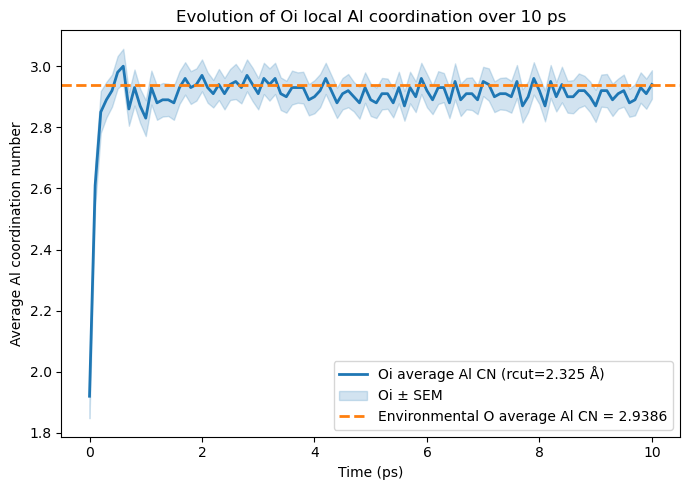

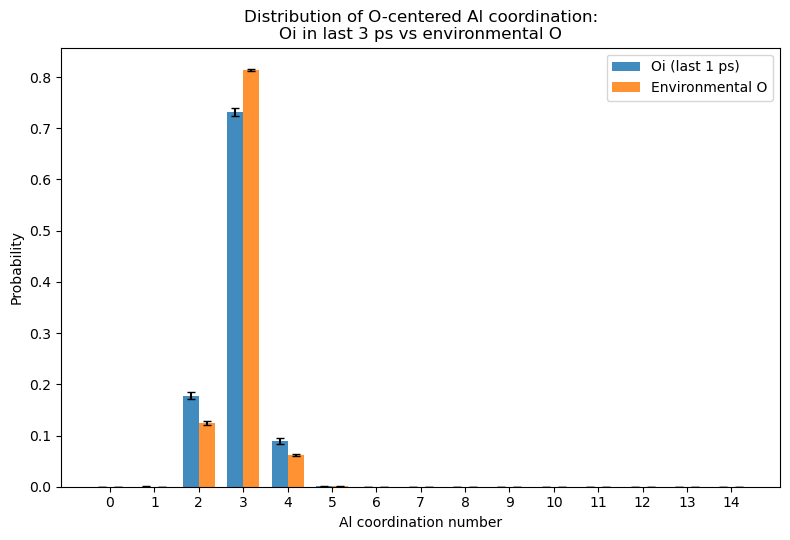


Saved files:
oi_al_cn_analysis\Fig1_Oi_Al_CN_avg_vs_time.png
oi_al_cn_analysis\Fig2_last1ps_Oi_vs_env_distribution.png
oi_al_cn_analysis\Fig2_last1ps_distribution_comparison.csv


In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# User settings
# =========================
TRAJ_PATTERN = "traj_E*.lammpstrj"
OI_TYPE = 3
AL_TYPES = {1, 4}
RCUT = 2.325
TIMESTEP_PS = 0.001            # metal units: 0.001 ps = 1 fs
ENV_O_MEAN_CN = 2.9386         # environmental O average Al CN
LAST_WINDOW_PS = 3.0           # use last 1 ps for Oi distribution
OUTPUT_DIR = "oi_al_cn_analysis"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Environmental O-centered O-Al CN distribution provided by you
env_dist = {
    0: 0.000000,
    1: 0.000001,
    2: 0.124055,
    3: 0.813779,
    4: 0.061690,
    5: 0.000476,
    6: 0.000000,
    7: 0.000000,
    8: 0.000000,
    9: 0.000000,
    10: 0.000000,
    11: 0.000000,
    12: 0.000000,
    13: 0.000000,
    14: 0.000000
}

env_se = {
    0: 0.000000,
    1: 0.000001,
    2: 0.003367,
    3: 0.002690,
    4: 0.002661,
    5: 0.000151,
    6: 0.000000,
    7: 0.000000,
    8: 0.000000,
    9: 0.000000,
    10: 0.000000,
    11: 0.000000,
    12: 0.000000,
    13: 0.000000,
    14: 0.000000
}


# =========================
# Helpers
# =========================
def minimum_image(delta, box_lengths):
    return delta - box_lengths * np.round(delta / box_lengths)


def parse_lammpstrj(filename):
    frames = []

    with open(filename, "r") as f:
        lines = f.readlines()

    i = 0
    nlines = len(lines)

    while i < nlines:
        if not lines[i].startswith("ITEM: TIMESTEP"):
            i += 1
            continue

        step = int(lines[i + 1].strip())

        if not lines[i + 2].startswith("ITEM: NUMBER OF ATOMS"):
            raise ValueError(f"{filename}: unexpected format near line {i+2}")
        natoms = int(lines[i + 3].strip())

        if not lines[i + 4].startswith("ITEM: BOX BOUNDS"):
            raise ValueError(f"{filename}: unexpected format near line {i+4}")

        xlo, xhi = map(float, lines[i + 5].split()[:2])
        ylo, yhi = map(float, lines[i + 6].split()[:2])
        zlo, zhi = map(float, lines[i + 7].split()[:2])
        box = np.array([xhi - xlo, yhi - ylo, zhi - zlo], dtype=float)

        atom_header = lines[i + 8].strip()
        if not atom_header.startswith("ITEM: ATOMS"):
            raise ValueError(f"{filename}: unexpected format near line {i+8}")

        cols = atom_header.split()[2:]
        col_index = {c: idx for idx, c in enumerate(cols)}

        required = ["id", "type", "x", "y", "z"]
        for r in required:
            if r not in col_index:
                raise ValueError(f"{filename}: missing required column '{r}'")

        atom_block = lines[i + 9:i + 9 + natoms]
        data = np.array([row.split() for row in atom_block], dtype=float)

        ids = data[:, col_index["id"]].astype(int)
        types = data[:, col_index["type"]].astype(int)
        coords = np.column_stack([
            data[:, col_index["x"]],
            data[:, col_index["y"]],
            data[:, col_index["z"]],
        ])

        frames.append({
            "step": step,
            "time_ps": step * TIMESTEP_PS,
            "box": box,
            "ids": ids,
            "types": types,
            "coords": coords,
        })

        i = i + 9 + natoms

    return frames


def compute_oi_al_cn(frame, oi_type=OI_TYPE, al_types=AL_TYPES, rcut=RCUT):
    """
    CN of Oi with respect to neighboring Al atoms only.
    """
    types = frame["types"]
    coords = frame["coords"]
    box = frame["box"]

    oi_idx = np.where(types == oi_type)[0]
    if len(oi_idx) != 1:
        raise ValueError(
            f"Expected exactly 1 Oi atom (type={oi_type}), found {len(oi_idx)} at step {frame['step']}"
        )

    oi_pos = coords[oi_idx[0]]

    al_idx = np.where(np.isin(types, list(al_types)))[0]
    al_pos = coords[al_idx]

    delta = al_pos - oi_pos
    delta = minimum_image(delta, box)
    dist = np.linalg.norm(delta, axis=1)

    cn = np.sum(dist <= rcut)
    return int(cn)


# =========================
# Main analysis
# =========================
traj_files = sorted(glob.glob(TRAJ_PATTERN))
if len(traj_files) == 0:
    raise FileNotFoundError(f"No files matched pattern: {TRAJ_PATTERN}")

print(f"Found {len(traj_files)} trajectory files.")

all_event_series = []
common_times = None

for traj_file in traj_files:
    print(f"Processing {traj_file} ...")
    frames = parse_lammpstrj(traj_file)

    times = np.array([fr["time_ps"] for fr in frames], dtype=float)
    cns = np.array([compute_oi_al_cn(fr) for fr in frames], dtype=int)

    if common_times is None:
        common_times = times
    else:
        if len(times) != len(common_times) or not np.allclose(times, common_times):
            raise ValueError(f"Time grid mismatch in file {traj_file}")

    event_name = os.path.splitext(os.path.basename(traj_file))[0]
    df_event = pd.DataFrame({
        "time_ps": times,
        "Oi_Al_CN": cns,
        "event": event_name
    })
    all_event_series.append(df_event)
    df_event.to_csv(os.path.join(OUTPUT_DIR, f"{event_name}_Oi_Al_CN.csv"), index=False)

df_all = pd.concat(all_event_series, ignore_index=True)

# average vs time
df_avg = (
    df_all.groupby("time_ps")["Oi_Al_CN"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={"mean": "CN_mean", "std": "CN_std", "count": "n_events"})
)
df_avg["CN_sem"] = df_avg["CN_std"] / np.sqrt(df_avg["n_events"])

df_all.to_csv(os.path.join(OUTPUT_DIR, "all_events_Oi_Al_CN_long.csv"), index=False)
df_avg.to_csv(os.path.join(OUTPUT_DIR, "Oi_Al_CN_avg_vs_time.csv"), index=False)

# =========================
# Figure 1: time evolution
# =========================
plt.figure(figsize=(7, 5))

# Oi curve in blue
plt.plot(
    df_avg["time_ps"],
    df_avg["CN_mean"],
    color="tab:blue",
    linewidth=2,
    label=f"Oi average Al CN (rcut={RCUT:.3f} Å)"
)

plt.fill_between(
    df_avg["time_ps"],
    df_avg["CN_mean"] - df_avg["CN_sem"],
    df_avg["CN_mean"] + df_avg["CN_sem"],
    color="tab:blue",
    alpha=0.20,
    label="Oi ± SEM"
)

# Environment line in orange
plt.axhline(
    y=ENV_O_MEAN_CN,
    color="tab:orange",
    linestyle="--",
    linewidth=2,
    label=f"Environmental O average Al CN = {ENV_O_MEAN_CN:.4f}"
)

plt.xlabel("Time (ps)")
plt.ylabel("Average Al coordination number")
plt.title("Evolution of Oi local Al coordination over 10 ps")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Fig1_Oi_Al_CN_avg_vs_time.png"), dpi=300)
plt.show()

# =========================
# Figure 2: distribution over last 1 ps
# =========================
tmax = df_all["time_ps"].max()
tmin_last = tmax - LAST_WINDOW_PS

df_last = df_all[df_all["time_ps"] >= tmin_last].copy()

# Oi distribution from last 1 ps of all events/frames
oi_counts = df_last["Oi_Al_CN"].value_counts().sort_index()

max_cn_seen = max(
    max(oi_counts.index) if len(oi_counts) > 0 else 0,
    max(env_dist.keys())
)
cn_values = np.arange(0, max_cn_seen + 1)

oi_prob = np.array([oi_counts.get(cn, 0) for cn in cn_values], dtype=float)
oi_prob = oi_prob / oi_prob.sum()

# simple binomial-style SE from sampled proportions
N_oi = len(df_last)
oi_se = np.sqrt(oi_prob * (1 - oi_prob) / N_oi)

env_prob = np.array([env_dist.get(cn, 0.0) for cn in cn_values], dtype=float)
env_prob_se = np.array([env_se.get(cn, 0.0) for cn in cn_values], dtype=float)

# save comparison table
df_dist_compare = pd.DataFrame({
    "CN": cn_values,
    "Oi_prob_last_1ps": oi_prob,
    "Oi_se_last_1ps": oi_se,
    "Env_O_prob": env_prob,
    "Env_O_se": env_prob_se
})
df_dist_compare.to_csv(
    os.path.join(OUTPUT_DIR, "Fig2_last1ps_distribution_comparison.csv"),
    index=False
)

# plot
plt.figure(figsize=(8, 5.5))
width = 0.36

plt.bar(
    cn_values - width/2,
    oi_prob,
    width=width,
    color="tab:blue",
    alpha=0.85,
    yerr=oi_se,
    capsize=3,
    label="Oi (last 3 ps)"
)

plt.bar(
    cn_values + width/2,
    env_prob,
    width=width,
    color="tab:orange",
    alpha=0.85,
    yerr=env_prob_se,
    capsize=3,
    label="Environmental O"
)

plt.xlabel("Al coordination number")
plt.ylabel("Probability")
plt.title("Distribution of O-centered Al coordination:\nOi in last 3 ps vs environmental O")
plt.xticks(cn_values)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Fig2_last1ps_Oi_vs_env_distribution.png"), dpi=300)
plt.show()

print("\nSaved files:")
print(os.path.join(OUTPUT_DIR, "Fig1_Oi_Al_CN_avg_vs_time.png"))
print(os.path.join(OUTPUT_DIR, "Fig2_last1ps_Oi_vs_env_distribution.png"))
print(os.path.join(OUTPUT_DIR, "Fig2_last1ps_distribution_comparison.csv"))

Found 100 trajectory files.
Processing traj_E001.lammpstrj ...
Processing traj_E002.lammpstrj ...
Processing traj_E003.lammpstrj ...
Processing traj_E004.lammpstrj ...
Processing traj_E005.lammpstrj ...
Processing traj_E006.lammpstrj ...
Processing traj_E007.lammpstrj ...
Processing traj_E008.lammpstrj ...
Processing traj_E009.lammpstrj ...
Processing traj_E010.lammpstrj ...
Processing traj_E011.lammpstrj ...
Processing traj_E012.lammpstrj ...
Processing traj_E013.lammpstrj ...
Processing traj_E014.lammpstrj ...
Processing traj_E015.lammpstrj ...
Processing traj_E016.lammpstrj ...
Processing traj_E017.lammpstrj ...
Processing traj_E018.lammpstrj ...
Processing traj_E019.lammpstrj ...
Processing traj_E020.lammpstrj ...
Processing traj_E021.lammpstrj ...
Processing traj_E022.lammpstrj ...
Processing traj_E023.lammpstrj ...
Processing traj_E024.lammpstrj ...
Processing traj_E025.lammpstrj ...
Processing traj_E026.lammpstrj ...
Processing traj_E027.lammpstrj ...
Processing traj_E028.lammps

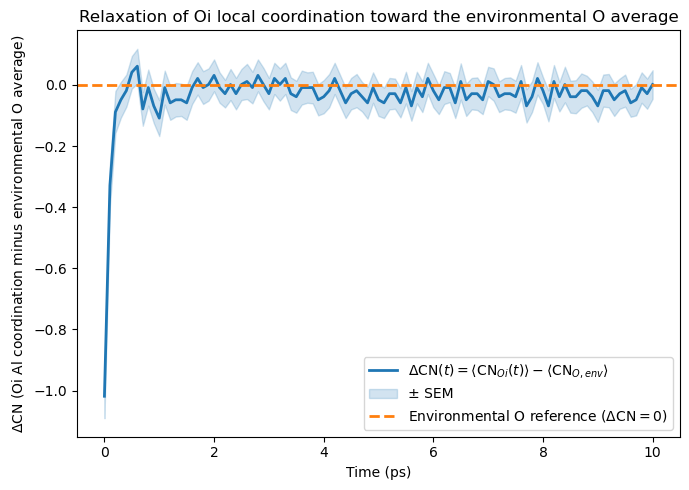


Saved:
oi_delta_cn_analysis\Oi_delta_CN_vs_time.csv
oi_delta_cn_analysis\Oi_delta_CN_vs_time.png


In [4]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# User settings
# =========================
TRAJ_PATTERN = "traj_E*.lammpstrj"
OI_TYPE = 3
AL_TYPES = {1, 4}
RCUT = 2.325
TIMESTEP_PS = 0.001            # metal units: 0.001 ps = 1 fs
ENV_O_MEAN_CN = 2.9386         # environmental O average Al CN
OUTPUT_DIR = "oi_delta_cn_analysis"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# =========================
# Helpers
# =========================
def minimum_image(delta, box_lengths):
    return delta - box_lengths * np.round(delta / box_lengths)


def parse_lammpstrj(filename):
    frames = []

    with open(filename, "r") as f:
        lines = f.readlines()

    i = 0
    nlines = len(lines)

    while i < nlines:
        if not lines[i].startswith("ITEM: TIMESTEP"):
            i += 1
            continue

        step = int(lines[i + 1].strip())

        if not lines[i + 2].startswith("ITEM: NUMBER OF ATOMS"):
            raise ValueError(f"{filename}: unexpected format near line {i+2}")
        natoms = int(lines[i + 3].strip())

        if not lines[i + 4].startswith("ITEM: BOX BOUNDS"):
            raise ValueError(f"{filename}: unexpected format near line {i+4}")

        xlo, xhi = map(float, lines[i + 5].split()[:2])
        ylo, yhi = map(float, lines[i + 6].split()[:2])
        zlo, zhi = map(float, lines[i + 7].split()[:2])
        box = np.array([xhi - xlo, yhi - ylo, zhi - zlo], dtype=float)

        atom_header = lines[i + 8].strip()
        if not atom_header.startswith("ITEM: ATOMS"):
            raise ValueError(f"{filename}: unexpected format near line {i+8}")

        cols = atom_header.split()[2:]
        col_index = {c: idx for idx, c in enumerate(cols)}

        required = ["id", "type", "x", "y", "z"]
        for r in required:
            if r not in col_index:
                raise ValueError(f"{filename}: missing required column '{r}'")

        atom_block = lines[i + 9:i + 9 + natoms]
        data = np.array([row.split() for row in atom_block], dtype=float)

        ids = data[:, col_index["id"]].astype(int)
        types = data[:, col_index["type"]].astype(int)
        coords = np.column_stack([
            data[:, col_index["x"]],
            data[:, col_index["y"]],
            data[:, col_index["z"]],
        ])

        frames.append({
            "step": step,
            "time_ps": step * TIMESTEP_PS,
            "box": box,
            "ids": ids,
            "types": types,
            "coords": coords,
        })

        i = i + 9 + natoms

    return frames


def compute_oi_al_cn(frame, oi_type=OI_TYPE, al_types=AL_TYPES, rcut=RCUT):
    """
    CN of Oi with respect to neighboring Al atoms only.
    """
    types = frame["types"]
    coords = frame["coords"]
    box = frame["box"]

    oi_idx = np.where(types == oi_type)[0]
    if len(oi_idx) != 1:
        raise ValueError(
            f"Expected exactly 1 Oi atom (type={oi_type}), found {len(oi_idx)} at step {frame['step']}"
        )

    oi_pos = coords[oi_idx[0]]

    al_idx = np.where(np.isin(types, list(al_types)))[0]
    al_pos = coords[al_idx]

    delta = al_pos - oi_pos
    delta = minimum_image(delta, box)
    dist = np.linalg.norm(delta, axis=1)

    cn = np.sum(dist <= rcut)
    return int(cn)


# =========================
# Main analysis
# =========================
traj_files = sorted(glob.glob(TRAJ_PATTERN))
if len(traj_files) == 0:
    raise FileNotFoundError(f"No files matched pattern: {TRAJ_PATTERN}")

print(f"Found {len(traj_files)} trajectory files.")

all_event_series = []
common_times = None

for traj_file in traj_files:
    print(f"Processing {traj_file} ...")
    frames = parse_lammpstrj(traj_file)

    times = np.array([fr["time_ps"] for fr in frames], dtype=float)
    cns = np.array([compute_oi_al_cn(fr) for fr in frames], dtype=float)

    if common_times is None:
        common_times = times
    else:
        if len(times) != len(common_times) or not np.allclose(times, common_times):
            raise ValueError(f"Time grid mismatch in file {traj_file}")

    event_name = os.path.splitext(os.path.basename(traj_file))[0]
    df_event = pd.DataFrame({
        "time_ps": times,
        "Oi_Al_CN": cns,
        "event": event_name
    })
    all_event_series.append(df_event)

# combine
df_all = pd.concat(all_event_series, ignore_index=True)

# average over events at each time
df_avg = (
    df_all.groupby("time_ps")["Oi_Al_CN"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={
        "mean": "CN_mean",
        "std": "CN_std",
        "count": "n_events"
    })
)

df_avg["CN_sem"] = df_avg["CN_std"] / np.sqrt(df_avg["n_events"])

# delta CN
df_avg["delta_CN"] = df_avg["CN_mean"] - ENV_O_MEAN_CN
df_avg["delta_CN_upper"] = df_avg["delta_CN"] + df_avg["CN_sem"]
df_avg["delta_CN_lower"] = df_avg["delta_CN"] - df_avg["CN_sem"]

# save data
df_avg.to_csv(os.path.join(OUTPUT_DIR, "Oi_delta_CN_vs_time.csv"), index=False)

# =========================
# Plot main figure only
# =========================
plt.figure(figsize=(7, 5))

plt.plot(
    df_avg["time_ps"],
    df_avg["delta_CN"],
    color="tab:blue",
    linewidth=2,
    label=r"$\Delta \mathrm{CN}(t)=\langle \mathrm{CN}_{Oi}(t)\rangle-\langle \mathrm{CN}_{O,env}\rangle$"
)

plt.fill_between(
    df_avg["time_ps"],
    df_avg["delta_CN_lower"],
    df_avg["delta_CN_upper"],
    color="tab:blue",
    alpha=0.20,
    label="± SEM"
)

plt.axhline(
    y=0.0,
    color="tab:orange",
    linestyle="--",
    linewidth=2,
    label=r"Environmental O reference ($\Delta \mathrm{CN}=0$)"
)

plt.xlabel("Time (ps)")
plt.ylabel(r"$\Delta$CN (Oi Al coordination minus environmental O average)")
plt.title(r"Relaxation of Oi local coordination toward the environmental O average")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Oi_delta_CN_vs_time.png"), dpi=300)
plt.show()

print("\nSaved:")
print(os.path.join(OUTPUT_DIR, "Oi_delta_CN_vs_time.csv"))
print(os.path.join(OUTPUT_DIR, "Oi_delta_CN_vs_time.png"))

In [8]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# User settings
# =========================
TRAJ_PATTERN = "traj_E*.lammpstrj"
OI_TYPE = 3
AL_TYPES = {1, 4}
RCUT = 2.325
TIMESTEP_PS = 0.001   # metal units: timestep 0.001 ps = 1 fs
N_CLOSEST = 5
OUTPUT_ROOT = "oi_event_figures"


# =========================
# Helpers
# =========================
def minimum_image(delta, box_lengths):
    return delta - box_lengths * np.round(delta / box_lengths)


def parse_lammpstrj(filename):
    frames = []

    with open(filename, "r") as f:
        lines = f.readlines()

    i = 0
    nlines = len(lines)

    while i < nlines:
        if not lines[i].startswith("ITEM: TIMESTEP"):
            i += 1
            continue

        step = int(lines[i + 1].strip())
        natoms = int(lines[i + 3].strip())

        xlo, xhi = map(float, lines[i + 5].split()[:2])
        ylo, yhi = map(float, lines[i + 6].split()[:2])
        zlo, zhi = map(float, lines[i + 7].split()[:2])
        box = np.array([xhi - xlo, yhi - ylo, zhi - zlo], dtype=float)

        atom_header = lines[i + 8].strip()
        cols = atom_header.split()[2:]
        col_index = {c: idx for idx, c in enumerate(cols)}

        atom_block = lines[i + 9:i + 9 + natoms]
        data = np.array([row.split() for row in atom_block], dtype=float)

        ids = data[:, col_index["id"]].astype(int)
        types = data[:, col_index["type"]].astype(int)
        coords = np.column_stack([
            data[:, col_index["x"]],
            data[:, col_index["y"]],
            data[:, col_index["z"]],
        ])

        frames.append({
            "step": step,
            "time_ps": step * TIMESTEP_PS,
            "box": box,
            "ids": ids,
            "types": types,
            "coords": coords,
        })

        i = i + 9 + natoms

    return frames


def get_oi_and_al_distances(frame, oi_type=OI_TYPE, al_types=AL_TYPES):
    ids = frame["ids"]
    types = frame["types"]
    coords = frame["coords"]
    box = frame["box"]

    oi_idx = np.where(types == oi_type)[0]
    if len(oi_idx) != 1:
        raise ValueError(
            f"Expected exactly 1 Oi atom (type={oi_type}), found {len(oi_idx)} at step {frame['step']}"
        )

    oi_idx = oi_idx[0]
    oi_id = int(ids[oi_idx])
    oi_pos = coords[oi_idx]

    al_idx = np.where(np.isin(types, list(al_types)))[0]
    al_ids = ids[al_idx].astype(int)
    al_pos = coords[al_idx]

    delta = al_pos - oi_pos
    delta_mic = minimum_image(delta, box)
    dist = np.linalg.norm(delta_mic, axis=1)

    return oi_id, oi_pos, al_ids, dist


def build_event_data(frames, oi_type=OI_TYPE, al_types=AL_TYPES, rcut=RCUT, n_closest=N_CLOSEST):
    """
    For one trajectory/event:
    1) build time series of Oi MIC displacement and CN
    2) identify top-N closest Al across whole trajectory
    3) build distance-vs-time table for those top-N Al
    """
    if len(frames) == 0:
        raise ValueError("Empty trajectory")

    # first frame reference
    oi_id0, oi_pos0, _, _ = get_oi_and_al_distances(frames[0], oi_type, al_types)

    # per-frame records
    ts_records = []
    all_dist_records = []

    for fr in frames:
        oi_id, oi_pos, al_ids, dists = get_oi_and_al_distances(fr, oi_type, al_types)

        dr = oi_pos - oi_pos0
        dr_mic = minimum_image(dr, fr["box"])
        rmic = float(np.linalg.norm(dr_mic))
        cn = int(np.sum(dists <= rcut))

        ts_records.append({
            "step": fr["step"],
            "time_ps": fr["time_ps"],
            "oi_id": oi_id,
            "oi_x": oi_pos[0],
            "oi_y": oi_pos[1],
            "oi_z": oi_pos[2],
            "rmic_Oi_A": rmic,
            "CN_Oi_Al": cn
        })

        for aid, d in zip(al_ids, dists):
            all_dist_records.append({
                "step": fr["step"],
                "time_ps": fr["time_ps"],
                "al_id": int(aid),
                "dist_A": float(d)
            })

    df_ts = pd.DataFrame(ts_records)
    df_all_dist = pd.DataFrame(all_dist_records)

    # choose top-N Al by minimum distance ever achieved
    df_min = (
        df_all_dist.groupby("al_id")["dist_A"]
        .min()
        .reset_index()
        .sort_values("dist_A", ascending=True)
    )
    top_ids = df_min["al_id"].head(n_closest).tolist()

    df_top = df_all_dist[df_all_dist["al_id"].isin(top_ids)].copy()
    df_pivot = df_top.pivot(index="time_ps", columns="al_id", values="dist_A").sort_index()

    return df_ts, df_pivot, top_ids


def save_three_plots(df_ts, df_pivot, top_ids, outdir, event_name, rcut=RCUT):
    # -------- Plot 1: rMIC --------
    plt.figure(figsize=(7, 4.5))
    plt.plot(df_ts["time_ps"], df_ts["rmic_Oi_A"], linewidth=2)
    plt.xlabel("Time (ps)")
    plt.ylabel(r"$r_{\mathrm{MIC},Oi}(t)$ (Å)")
    plt.title(f"{event_name}: Oi MIC displacement vs time")
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f"{event_name}_rmic_vs_time.png"), dpi=300)
    plt.close()

    # -------- Plot 2: CN --------
    plt.figure(figsize=(7, 4.5))
    plt.plot(df_ts["time_ps"], df_ts["CN_Oi_Al"], linewidth=2)
    plt.xlabel("Time (ps)")
    plt.ylabel("Oi-Al coordination number")
    plt.title(f"{event_name}: Oi local coordination vs time (cutoff = {rcut:.3f} Å)")
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f"{event_name}_cn_vs_time.png"), dpi=300)
    plt.close()

    # -------- Plot 3: top5 distances --------
    plt.figure(figsize=(8, 5.2))
    for al_id in df_pivot.columns:
        plt.plot(df_pivot.index, df_pivot[al_id], linewidth=2, label=f"Al {al_id}")

    plt.axhline(
        y=rcut,
        linestyle="--",
        linewidth=2,
        color="black",
        label=f"cutoff = {rcut:.3f} Å"
    )

    plt.xlabel("Time (ps)")
    plt.ylabel(r"$d_{\mathrm{Oi-Al}}(t)$ (Å)")
    plt.title(f"{event_name}: distances from Oi to the {len(top_ids)} closest Al atoms")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f"{event_name}_top{len(top_ids)}_al_distance_vs_time.png"), dpi=300)
    plt.close()


# =========================
# Main
# =========================
os.makedirs(OUTPUT_ROOT, exist_ok=True)

traj_files = sorted(glob.glob(TRAJ_PATTERN))
if len(traj_files) == 0:
    raise FileNotFoundError(f"No files matched pattern: {TRAJ_PATTERN}")

summary_rows = []

print(f"Found {len(traj_files)} trajectory files.")

for traj_file in traj_files:
    event_name = os.path.splitext(os.path.basename(traj_file))[0]
    print(f"Processing {event_name} ...")

    outdir = os.path.join(OUTPUT_ROOT, event_name)
    os.makedirs(outdir, exist_ok=True)

    try:
        frames = parse_lammpstrj(traj_file)
        df_ts, df_pivot, top_ids = build_event_data(
            frames,
            oi_type=OI_TYPE,
            al_types=AL_TYPES,
            rcut=RCUT,
            n_closest=N_CLOSEST
        )

        # save csvs
        df_ts.to_csv(os.path.join(outdir, f"{event_name}_timeseries.csv"), index=False)
        df_pivot.to_csv(os.path.join(outdir, f"{event_name}_top{len(top_ids)}_distance_table.csv"))

        # save figures
        save_three_plots(df_ts, df_pivot, top_ids, outdir, event_name, rcut=RCUT)

        summary_rows.append({
            "event": event_name,
            "n_frames": len(df_ts),
            "tmax_ps": df_ts["time_ps"].max(),
            "rmic_final_A": df_ts["rmic_Oi_A"].iloc[-1],
            "rmic_max_A": df_ts["rmic_Oi_A"].max(),
            "cn_initial": int(df_ts["CN_Oi_Al"].iloc[0]),
            "cn_final": int(df_ts["CN_Oi_Al"].iloc[-1]),
            "cn_mean": df_ts["CN_Oi_Al"].mean(),
            "top_al_ids": ";".join(map(str, top_ids))
        })

    except Exception as e:
        print(f"  Failed for {event_name}: {e}")
        summary_rows.append({
            "event": event_name,
            "error": str(e)
        })

# save summary
df_summary = pd.DataFrame(summary_rows)
summary_path = os.path.join(OUTPUT_ROOT, "all_events_summary.csv")
df_summary.to_csv(summary_path, index=False)

print("\nDone.")
print(f"Figures and CSVs saved under: {OUTPUT_ROOT}")
print(f"Summary saved to: {summary_path}")

Found 100 trajectory files.
Processing traj_E001 ...
Processing traj_E002 ...
Processing traj_E003 ...
Processing traj_E004 ...
Processing traj_E005 ...
Processing traj_E006 ...
Processing traj_E007 ...
Processing traj_E008 ...
Processing traj_E009 ...
Processing traj_E010 ...
Processing traj_E011 ...
Processing traj_E012 ...
Processing traj_E013 ...
Processing traj_E014 ...
Processing traj_E015 ...
Processing traj_E016 ...
Processing traj_E017 ...
Processing traj_E018 ...
Processing traj_E019 ...
Processing traj_E020 ...
Processing traj_E021 ...
Processing traj_E022 ...
Processing traj_E023 ...
Processing traj_E024 ...
Processing traj_E025 ...
Processing traj_E026 ...
Processing traj_E027 ...
Processing traj_E028 ...
Processing traj_E029 ...
Processing traj_E030 ...
Processing traj_E031 ...
Processing traj_E032 ...
Processing traj_E033 ...
Processing traj_E034 ...
Processing traj_E035 ...
Processing traj_E036 ...
Processing traj_E037 ...
Processing traj_E038 ...
Processing traj_E039 .

Found 100 trajectory files.
Processing traj_E001 ...
Processing traj_E002 ...
Processing traj_E003 ...
Processing traj_E004 ...
Processing traj_E005 ...
Processing traj_E006 ...
Processing traj_E007 ...
Processing traj_E008 ...
Processing traj_E009 ...
Processing traj_E010 ...
Processing traj_E011 ...
Processing traj_E012 ...
Processing traj_E013 ...
Processing traj_E014 ...
Processing traj_E015 ...
Processing traj_E016 ...
Processing traj_E017 ...
Processing traj_E018 ...
Processing traj_E019 ...
Processing traj_E020 ...
Processing traj_E021 ...
Processing traj_E022 ...
Processing traj_E023 ...
Processing traj_E024 ...
Processing traj_E025 ...
Processing traj_E026 ...
Processing traj_E027 ...
Processing traj_E028 ...
Processing traj_E029 ...
Processing traj_E030 ...
Processing traj_E031 ...
Processing traj_E032 ...
Processing traj_E033 ...
Processing traj_E034 ...
Processing traj_E035 ...
Processing traj_E036 ...
Processing traj_E037 ...
Processing traj_E038 ...
Processing traj_E039 .

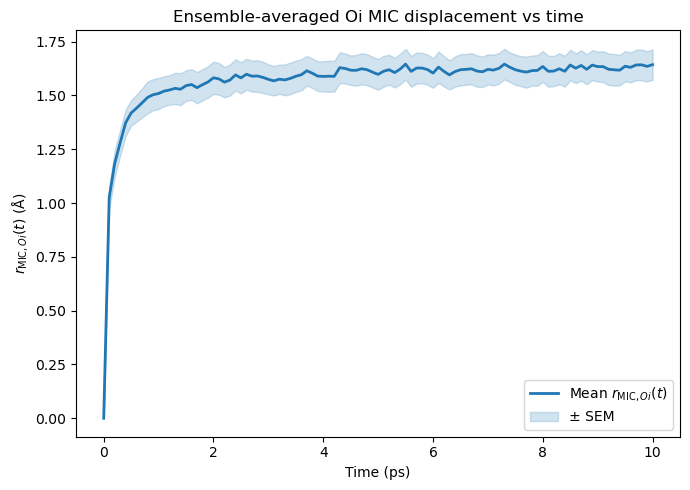


Saved:
macro_rmic_oi\macro_rmic_Oi_vs_time.csv
macro_rmic_oi\macro_rmic_Oi_vs_time.png


In [9]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# User settings
# =========================
TRAJ_PATTERN = "traj_E*.lammpstrj"
OI_TYPE = 3
TIMESTEP_PS = 0.001   # metal units: timestep 0.001 ps = 1 fs
OUTPUT_DIR = "macro_rmic_oi"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# =========================
# Helpers
# =========================
def minimum_image(delta, box_lengths):
    return delta - box_lengths * np.round(delta / box_lengths)


def parse_lammpstrj(filename):
    frames = []

    with open(filename, "r") as f:
        lines = f.readlines()

    i = 0
    nlines = len(lines)

    while i < nlines:
        if not lines[i].startswith("ITEM: TIMESTEP"):
            i += 1
            continue

        step = int(lines[i + 1].strip())
        natoms = int(lines[i + 3].strip())

        xlo, xhi = map(float, lines[i + 5].split()[:2])
        ylo, yhi = map(float, lines[i + 6].split()[:2])
        zlo, zhi = map(float, lines[i + 7].split()[:2])
        box = np.array([xhi - xlo, yhi - ylo, zhi - zlo], dtype=float)

        atom_header = lines[i + 8].strip()
        cols = atom_header.split()[2:]
        col_index = {c: idx for idx, c in enumerate(cols)}

        atom_block = lines[i + 9:i + 9 + natoms]
        data = np.array([row.split() for row in atom_block], dtype=float)

        ids = data[:, col_index["id"]].astype(int)
        types = data[:, col_index["type"]].astype(int)
        coords = np.column_stack([
            data[:, col_index["x"]],
            data[:, col_index["y"]],
            data[:, col_index["z"]],
        ])

        frames.append({
            "step": step,
            "time_ps": step * TIMESTEP_PS,
            "box": box,
            "ids": ids,
            "types": types,
            "coords": coords,
        })

        i = i + 9 + natoms

    return frames


def get_oi_position(frame, oi_type=OI_TYPE):
    types = frame["types"]
    coords = frame["coords"]

    oi_idx = np.where(types == oi_type)[0]
    if len(oi_idx) != 1:
        raise ValueError(
            f"Expected exactly 1 Oi atom (type={oi_type}), found {len(oi_idx)} at step {frame['step']}"
        )

    return coords[oi_idx[0]]


# =========================
# Main analysis
# =========================
traj_files = sorted(glob.glob(TRAJ_PATTERN))
if len(traj_files) == 0:
    raise FileNotFoundError(f"No files matched pattern: {TRAJ_PATTERN}")

print(f"Found {len(traj_files)} trajectory files.")

all_event_series = []
common_times = None

for traj_file in traj_files:
    event_name = os.path.splitext(os.path.basename(traj_file))[0]
    print(f"Processing {event_name} ...")

    frames = parse_lammpstrj(traj_file)
    if len(frames) == 0:
        continue

    oi_pos0 = get_oi_position(frames[0])

    times = []
    rmic_list = []

    for fr in frames:
        oi_pos = get_oi_position(fr)

        dr = oi_pos - oi_pos0
        dr_mic = minimum_image(dr, fr["box"])
        rmic = np.linalg.norm(dr_mic)

        times.append(fr["time_ps"])
        rmic_list.append(rmic)

    times = np.array(times, dtype=float)
    rmic_list = np.array(rmic_list, dtype=float)

    if common_times is None:
        common_times = times
    else:
        if len(times) != len(common_times) or not np.allclose(times, common_times):
            raise ValueError(f"Time grid mismatch in file {traj_file}")

    df_event = pd.DataFrame({
        "time_ps": times,
        "rmic_Oi_A": rmic_list,
        "event": event_name
    })
    all_event_series.append(df_event)

# combine all events
df_all = pd.concat(all_event_series, ignore_index=True)

# average over events at each time
df_avg = (
    df_all.groupby("time_ps")["rmic_Oi_A"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={
        "mean": "rmic_mean_A",
        "std": "rmic_std_A",
        "count": "n_events"
    })
)

df_avg["rmic_sem_A"] = df_avg["rmic_std_A"] / np.sqrt(df_avg["n_events"])

# save data
df_all.to_csv(os.path.join(OUTPUT_DIR, "all_events_rmic_Oi_long.csv"), index=False)
df_avg.to_csv(os.path.join(OUTPUT_DIR, "macro_rmic_Oi_vs_time.csv"), index=False)

# =========================
# Plot
# =========================
plt.figure(figsize=(7, 5))

plt.plot(
    df_avg["time_ps"],
    df_avg["rmic_mean_A"],
    color="tab:blue",
    linewidth=2,
    label=r"Mean $r_{\mathrm{MIC},Oi}(t)$"
)

plt.fill_between(
    df_avg["time_ps"],
    df_avg["rmic_mean_A"] - df_avg["rmic_sem_A"],
    df_avg["rmic_mean_A"] + df_avg["rmic_sem_A"],
    color="tab:blue",
    alpha=0.20,
    label="± SEM"
)

plt.xlabel("Time (ps)")
plt.ylabel(r"$r_{\mathrm{MIC},Oi}(t)$ (Å)")
plt.title("Ensemble-averaged Oi MIC displacement vs time")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "macro_rmic_Oi_vs_time.png"), dpi=300)
plt.show()

print("\nSaved:")
print(os.path.join(OUTPUT_DIR, "macro_rmic_Oi_vs_time.csv"))
print(os.path.join(OUTPUT_DIR, "macro_rmic_Oi_vs_time.png"))

Found 100 trajectory files.
Processing traj_E001 ...
Processing traj_E002 ...
Processing traj_E003 ...
Processing traj_E004 ...
Processing traj_E005 ...
Processing traj_E006 ...
Processing traj_E007 ...
Processing traj_E008 ...
Processing traj_E009 ...
Processing traj_E010 ...
Processing traj_E011 ...
Processing traj_E012 ...
Processing traj_E013 ...
Processing traj_E014 ...
Processing traj_E015 ...
Processing traj_E016 ...
Processing traj_E017 ...
Processing traj_E018 ...
Processing traj_E019 ...
Processing traj_E020 ...
Processing traj_E021 ...
Processing traj_E022 ...
Processing traj_E023 ...
Processing traj_E024 ...
Processing traj_E025 ...
Processing traj_E026 ...
Processing traj_E027 ...
Processing traj_E028 ...
Processing traj_E029 ...
Processing traj_E030 ...
Processing traj_E031 ...
Processing traj_E032 ...
Processing traj_E033 ...
Processing traj_E034 ...
Processing traj_E035 ...
Processing traj_E036 ...
Processing traj_E037 ...
Processing traj_E038 ...
Processing traj_E039 .

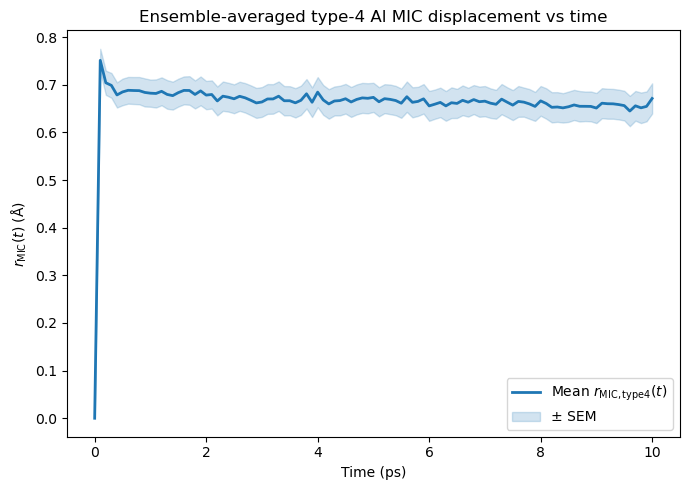

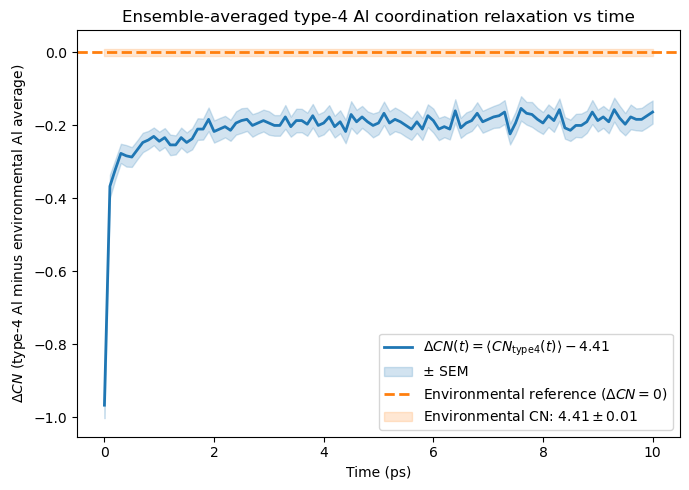


Saved:
macro_type4_al_analysis\all_events_type4_long.csv
macro_type4_al_analysis\macro_rmic_type4_vs_time.csv
macro_type4_al_analysis\macro_deltaCN_type4_vs_time.csv
macro_type4_al_analysis\macro_rmic_type4_vs_time.png
macro_type4_al_analysis\macro_deltaCN_type4_vs_time.png


In [5]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# User settings
# =========================
TRAJ_PATTERN = "traj_E*.lammpstrj"

OV_CORE_AL_TYPE = 4        # three type-4 Al per event
O_TYPES = {2, 3}           # O neighbours around type-4 Al; use {2} if you want to exclude Oi
RCUT_ALO = 2.325           # Al-O cutoff in Angstrom
TIMESTEP_PS = 0.001        # metal units: timestep 0.001 ps = 1 fs

ENV_CN = 4.41
ENV_CN_ERR = 0.01

OUTPUT_DIR = "macro_type4_al_analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# =========================
# Helpers
# =========================
def minimum_image(delta, box_lengths):
    return delta - box_lengths * np.round(delta / box_lengths)


def parse_lammpstrj(filename):
    frames = []

    with open(filename, "r") as f:
        lines = f.readlines()

    i = 0
    nlines = len(lines)

    while i < nlines:
        if not lines[i].startswith("ITEM: TIMESTEP"):
            i += 1
            continue

        step = int(lines[i + 1].strip())
        natoms = int(lines[i + 3].strip())

        xlo, xhi = map(float, lines[i + 5].split()[:2])
        ylo, yhi = map(float, lines[i + 6].split()[:2])
        zlo, zhi = map(float, lines[i + 7].split()[:2])
        box = np.array([xhi - xlo, yhi - ylo, zhi - zlo], dtype=float)

        atom_header = lines[i + 8].strip()
        cols = atom_header.split()[2:]
        col_index = {c: idx for idx, c in enumerate(cols)}

        atom_block = lines[i + 9:i + 9 + natoms]
        data = np.array([row.split() for row in atom_block], dtype=float)

        ids = data[:, col_index["id"]].astype(int)
        types = data[:, col_index["type"]].astype(int)
        coords = np.column_stack([
            data[:, col_index["x"]],
            data[:, col_index["y"]],
            data[:, col_index["z"]],
        ])

        frames.append({
            "step": step,
            "time_ps": step * TIMESTEP_PS,
            "box": box,
            "ids": ids,
            "types": types,
            "coords": coords,
        })

        i = i + 9 + natoms

    return frames


def get_type4_positions_and_cns(frame, type4_type=OV_CORE_AL_TYPE, o_types=O_TYPES, rcut=RCUT_ALO):
    """
    Return all type-4 positions and their CNs in one frame.
    """
    types = frame["types"]
    coords = frame["coords"]
    box = frame["box"]

    t4_idx = np.where(types == type4_type)[0]
    if len(t4_idx) != 3:
        raise ValueError(
            f"Expected exactly 3 type-4 Al atoms, found {len(t4_idx)} at step {frame['step']}"
        )

    t4_pos = coords[t4_idx]  # shape (3, 3)

    o_idx = np.where(np.isin(types, list(o_types)))[0]
    o_pos = coords[o_idx]

    cns = []
    for pos in t4_pos:
        delta = o_pos - pos
        delta_mic = minimum_image(delta, box)
        dist = np.linalg.norm(delta_mic, axis=1)
        cn = int(np.sum(dist <= rcut))
        cns.append(cn)

    return t4_pos, np.array(cns, dtype=float)


def match_positions_by_nearest(prev_pos, curr_pos, box):
    """
    Match current 3 type-4 positions to initial 3 type-4 positions by minimum MIC distance.
    Since there are only 3 atoms, brute force all permutations.
    """
    from itertools import permutations

    best_perm = None
    best_cost = None

    for perm in permutations(range(3)):
        reordered = curr_pos[list(perm)]
        delta = reordered - prev_pos
        delta_mic = minimum_image(delta, box)
        d = np.linalg.norm(delta_mic, axis=1)
        cost = np.sum(d)

        if best_cost is None or cost < best_cost:
            best_cost = cost
            best_perm = perm

    return curr_pos[list(best_perm)]


# =========================
# Main analysis
# =========================
traj_files = sorted(glob.glob(TRAJ_PATTERN))
if len(traj_files) == 0:
    raise FileNotFoundError(f"No files matched pattern: {TRAJ_PATTERN}")

print(f"Found {len(traj_files)} trajectory files.")

all_event_series = []
common_times = None

for traj_file in traj_files:
    event_name = os.path.splitext(os.path.basename(traj_file))[0]
    print(f"Processing {event_name} ...")

    frames = parse_lammpstrj(traj_file)
    if len(frames) == 0:
        continue

    # initial positions of the 3 type-4 atoms
    pos0, _ = get_type4_positions_and_cns(frames[0])

    times = []
    rmic_mean_list = []
    rmic_std_list = []
    cn_mean_list = []
    cn_std_list = []

    for fr in frames:
        pos_t, cn_t = get_type4_positions_and_cns(fr)

        # match current type-4 positions to initial ones
        pos_t_matched = match_positions_by_nearest(pos0, pos_t, fr["box"])

        dr = pos_t_matched - pos0
        dr_mic = minimum_image(dr, fr["box"])
        rmic_each = np.linalg.norm(dr_mic, axis=1)

        times.append(fr["time_ps"])
        rmic_mean_list.append(np.mean(rmic_each))
        rmic_std_list.append(np.std(rmic_each, ddof=0))
        cn_mean_list.append(np.mean(cn_t))
        cn_std_list.append(np.std(cn_t, ddof=0))

    times = np.array(times, dtype=float)

    if common_times is None:
        common_times = times
    else:
        if len(times) != len(common_times) or not np.allclose(times, common_times):
            raise ValueError(f"Time grid mismatch in file {traj_file}")

    df_event = pd.DataFrame({
        "time_ps": times,
        "rmic_type4_mean_A": np.array(rmic_mean_list, dtype=float),
        "rmic_type4_std_A": np.array(rmic_std_list, dtype=float),
        "CN_type4_mean": np.array(cn_mean_list, dtype=float),
        "CN_type4_std": np.array(cn_std_list, dtype=float),
        "event": event_name
    })
    all_event_series.append(df_event)

# combine
df_all = pd.concat(all_event_series, ignore_index=True)

# average event-mean rMIC over events
df_rmic = (
    df_all.groupby("time_ps")["rmic_type4_mean_A"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={
        "mean": "rmic_mean_A",
        "std": "rmic_std_A",
        "count": "n_events"
    })
)
df_rmic["rmic_sem_A"] = df_rmic["rmic_std_A"] / np.sqrt(df_rmic["n_events"])

# average event-mean CN over events
df_cn = (
    df_all.groupby("time_ps")["CN_type4_mean"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={
        "mean": "CN_mean",
        "std": "CN_std",
        "count": "n_events"
    })
)
df_cn["CN_sem"] = df_cn["CN_std"] / np.sqrt(df_cn["n_events"])
df_cn["delta_CN"] = df_cn["CN_mean"] - ENV_CN
df_cn["delta_CN_upper"] = df_cn["delta_CN"] + df_cn["CN_sem"]
df_cn["delta_CN_lower"] = df_cn["delta_CN"] - df_cn["CN_sem"]

# save
df_all.to_csv(os.path.join(OUTPUT_DIR, "all_events_type4_long.csv"), index=False)
df_rmic.to_csv(os.path.join(OUTPUT_DIR, "macro_rmic_type4_vs_time.csv"), index=False)
df_cn.to_csv(os.path.join(OUTPUT_DIR, "macro_deltaCN_type4_vs_time.csv"), index=False)

# =========================
# Plot 1: average rMIC
# =========================
plt.figure(figsize=(7, 5))

plt.plot(
    df_rmic["time_ps"],
    df_rmic["rmic_mean_A"],
    color="tab:blue",
    linewidth=2,
    label=r"Mean $r_{\mathrm{MIC},\mathrm{type4}}(t)$"
)

plt.fill_between(
    df_rmic["time_ps"],
    df_rmic["rmic_mean_A"] - df_rmic["rmic_sem_A"],
    df_rmic["rmic_mean_A"] + df_rmic["rmic_sem_A"],
    color="tab:blue",
    alpha=0.20,
    label="± SEM"
)

plt.xlabel("Time (ps)")
plt.ylabel(r"$r_{\mathrm{MIC}}(t)$ (Å)")
plt.title("Ensemble-averaged type-4 Al MIC displacement vs time")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "macro_rmic_type4_vs_time.png"), dpi=300)
plt.show()

# =========================
# Plot 2: average delta CN
# =========================
plt.figure(figsize=(7, 5))

plt.plot(
    df_cn["time_ps"],
    df_cn["delta_CN"],
    color="tab:blue",
    linewidth=2,
    label=r"$\Delta CN(t)=\langle CN_{\mathrm{type4}}(t)\rangle-4.41$"
)

plt.fill_between(
    df_cn["time_ps"],
    df_cn["delta_CN_lower"],
    df_cn["delta_CN_upper"],
    color="tab:blue",
    alpha=0.20,
    label="± SEM"
)

plt.axhline(
    y=0.0,
    color="tab:orange",
    linestyle="--",
    linewidth=2,
    label=r"Environmental reference ($\Delta CN = 0$)"
)

plt.fill_between(
    df_cn["time_ps"],
    -ENV_CN_ERR,
    +ENV_CN_ERR,
    color="tab:orange",
    alpha=0.18,
    label=fr"Environmental CN: $4.41 \pm {ENV_CN_ERR:.2f}$"
)

plt.xlabel("Time (ps)")
plt.ylabel(r"$\Delta CN$ (type-4 Al minus environmental Al average)")
plt.title("Ensemble-averaged type-4 Al coordination relaxation vs time")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "macro_deltaCN_type4_vs_time.png"), dpi=300)
plt.show()

print("\nSaved:")
print(os.path.join(OUTPUT_DIR, "all_events_type4_long.csv"))
print(os.path.join(OUTPUT_DIR, "macro_rmic_type4_vs_time.csv"))
print(os.path.join(OUTPUT_DIR, "macro_deltaCN_type4_vs_time.csv"))
print(os.path.join(OUTPUT_DIR, "macro_rmic_type4_vs_time.png"))
print(os.path.join(OUTPUT_DIR, "macro_deltaCN_type4_vs_time.png"))

In [6]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import permutations

# =========================
# User settings
# =========================
TRAJ_PATTERN = "traj_E*.lammpstrj"

TYPE4 = 4
O_TYPES = {2, 3}          # use {2} if you want to exclude Oi
RCUT_ALO = 2.325
TIMESTEP_PS = 0.001
ENV_CN = 4.41

N_CLOSEST_O = 7
OUTPUT_ROOT = "ov_type4_event_figures"


# =========================
# Helpers
# =========================
def minimum_image(delta, box_lengths):
    return delta - box_lengths * np.round(delta / box_lengths)


def parse_lammpstrj(filename):
    frames = []

    with open(filename, "r") as f:
        lines = f.readlines()

    i = 0
    nlines = len(lines)

    while i < nlines:
        if not lines[i].startswith("ITEM: TIMESTEP"):
            i += 1
            continue

        step = int(lines[i + 1].strip())
        natoms = int(lines[i + 3].strip())

        xlo, xhi = map(float, lines[i + 5].split()[:2])
        ylo, yhi = map(float, lines[i + 6].split()[:2])
        zlo, zhi = map(float, lines[i + 7].split()[:2])
        box = np.array([xhi - xlo, yhi - ylo, zhi - zlo], dtype=float)

        atom_header = lines[i + 8].strip()
        cols = atom_header.split()[2:]
        col_index = {c: idx for idx, c in enumerate(cols)}

        atom_block = lines[i + 9:i + 9 + natoms]
        data = np.array([row.split() for row in atom_block], dtype=float)

        ids = data[:, col_index["id"]].astype(int)
        types = data[:, col_index["type"]].astype(int)
        coords = np.column_stack([
            data[:, col_index["x"]],
            data[:, col_index["y"]],
            data[:, col_index["z"]],
        ])

        frames.append({
            "step": step,
            "time_ps": step * TIMESTEP_PS,
            "box": box,
            "ids": ids,
            "types": types,
            "coords": coords,
        })

        i = i + 9 + natoms

    return frames


def get_type4_and_oxygen_data(frame, type4_type=TYPE4, o_types=O_TYPES):
    """
    Returns:
        type4_ids, type4_pos, o_ids, o_pos
    """
    ids = frame["ids"]
    types = frame["types"]
    coords = frame["coords"]

    t4_idx = np.where(types == type4_type)[0]
    if len(t4_idx) != 3:
        raise ValueError(f"Expected 3 type-4 atoms, found {len(t4_idx)} at step {frame['step']}")

    o_idx = np.where(np.isin(types, list(o_types)))[0]

    return (
        ids[t4_idx].astype(int),
        coords[t4_idx],
        ids[o_idx].astype(int),
        coords[o_idx],
    )


def match_type4_by_nearest(ref_pos, curr_pos, curr_ids, box):
    """
    Match current 3 type4 atoms to reference positions using minimum MIC distance.
    Returns reordered positions and ids.
    """
    best_perm = None
    best_cost = None

    for perm in permutations(range(3)):
        p = curr_pos[list(perm)]
        delta = p - ref_pos
        delta_mic = minimum_image(delta, box)
        cost = np.sum(np.linalg.norm(delta_mic, axis=1))

        if best_cost is None or cost < best_cost:
            best_cost = cost
            best_perm = perm

    perm = list(best_perm)
    return curr_pos[perm], curr_ids[perm]


def build_event_data(frames, rcut=RCUT_ALO, env_cn=ENV_CN, n_closest_o=N_CLOSEST_O):
    """
    For one event:
    - event-level average rMIC(t) over 3 type4 Al
    - event-level average deltaCN(t) over 3 type4 Al
    - for each of the 3 type4 Al, distance-vs-time table to its top-7 closest O/Oi atoms
    """
    if len(frames) == 0:
        raise ValueError("Empty trajectory")

    # initial reference
    t4_ids0, t4_pos0, _, _ = get_type4_and_oxygen_data(frames[0])

    # per-frame avg records
    avg_records = []

    # collect full distance records for each matched type4 index 0/1/2
    # key = matched index (0,1,2), values = list of dicts
    dist_records = {0: [], 1: [], 2: []}
    type4_id_track = {0: [], 1: [], 2: []}

    for fr in frames:
        t4_ids, t4_pos, o_ids, o_pos = get_type4_and_oxygen_data(fr)

        # match current 3 type4 atoms to reference order
        t4_pos_m, t4_ids_m = match_type4_by_nearest(t4_pos0, t4_pos, t4_ids, fr["box"])

        rmic_each = []
        cn_each = []

        for j in range(3):
            pos = t4_pos_m[j]

            # rMIC
            dr = pos - t4_pos0[j]
            dr_mic = minimum_image(dr, fr["box"])
            rmic = np.linalg.norm(dr_mic)
            rmic_each.append(rmic)

            # CN and all O distances
            delta = o_pos - pos
            delta_mic = minimum_image(delta, fr["box"])
            dists = np.linalg.norm(delta_mic, axis=1)

            cn = int(np.sum(dists <= rcut))
            cn_each.append(cn)

            type4_id_track[j].append(int(t4_ids_m[j]))

            for oid, d in zip(o_ids, dists):
                dist_records[j].append({
                    "time_ps": fr["time_ps"],
                    "step": fr["step"],
                    "type4_matched_index": j + 1,   # 1,2,3 for user-facing filenames
                    "type4_id": int(t4_ids_m[j]),
                    "o_id": int(oid),
                    "dist_A": float(d)
                })

        avg_records.append({
            "time_ps": fr["time_ps"],
            "step": fr["step"],
            "rmic_type4_avg_A": float(np.mean(rmic_each)),
            "rmic_type4_std_A": float(np.std(rmic_each, ddof=0)),
            "CN_type4_avg": float(np.mean(cn_each)),
            "CN_type4_std": float(np.std(cn_each, ddof=0)),
            "delta_CN_type4_avg": float(np.mean(cn_each) - env_cn),
        })

    df_avg = pd.DataFrame(avg_records)

    # for each type4, choose top-7 closest O/Oi atoms by minimum distance over whole trajectory
    top_tables = {}
    top_ids_summary = {}

    for j in range(3):
        dfj = pd.DataFrame(dist_records[j])

        df_min = (
            dfj.groupby("o_id")["dist_A"]
            .min()
            .reset_index()
            .sort_values("dist_A", ascending=True)
        )
        top_o_ids = df_min["o_id"].head(n_closest_o).tolist()
        top_ids_summary[j + 1] = top_o_ids

        df_top = dfj[dfj["o_id"].isin(top_o_ids)].copy()
        df_pivot = df_top.pivot(index="time_ps", columns="o_id", values="dist_A").sort_index()
        top_tables[j + 1] = df_pivot

    return df_avg, top_tables, top_ids_summary


def save_avg_plots(df_avg, outdir, event_name, env_cn=ENV_CN):
    # Plot 1: avg rMIC over 3 type4 Al
    plt.figure(figsize=(7, 4.8))
    plt.plot(df_avg["time_ps"], df_avg["rmic_type4_avg_A"], linewidth=2)
    plt.fill_between(
        df_avg["time_ps"],
        df_avg["rmic_type4_avg_A"] - df_avg["rmic_type4_std_A"],
        df_avg["rmic_type4_avg_A"] + df_avg["rmic_type4_std_A"],
        alpha=0.20
    )
    plt.xlabel("Time (ps)")
    plt.ylabel(r"$r_{\mathrm{MIC}}(t)$ (Å)")
    plt.title(f"{event_name}: average type-4 Al MIC displacement vs time")
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f"{event_name}_type4_avg_rmic_vs_time.png"), dpi=300)
    plt.close()

    # Plot 2: avg delta CN over 3 type4 Al
    plt.figure(figsize=(7, 4.8))
    plt.plot(df_avg["time_ps"], df_avg["delta_CN_type4_avg"], linewidth=2)
    plt.axhline(0.0, linestyle="--", linewidth=2, color="black")
    plt.xlabel("Time (ps)")
    plt.ylabel(r"$\Delta CN(t)$")
    plt.title(f"{event_name}: average type-4 Al coordination deviation vs time")
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f"{event_name}_type4_avg_deltaCN_vs_time.png"), dpi=300)
    plt.close()


def save_distance_plots(top_tables, outdir, event_name, rcut=RCUT_ALO):
    # Three plots, one per type4 Al
    for idx, df_pivot in top_tables.items():
        plt.figure(figsize=(8, 5.2))
        for oid in df_pivot.columns:
            plt.plot(df_pivot.index, df_pivot[oid], linewidth=2, label=f"O {oid}")

        plt.axhline(
            y=rcut,
            linestyle="--",
            linewidth=2,
            color="black",
            label=f"cutoff = {rcut:.3f} Å"
        )

        plt.xlabel("Time (ps)")
        plt.ylabel(r"$d_{\mathrm{type4-O}}(t)$ (Å)")
        plt.title(f"{event_name}: distances from type4-{idx} Al to the {len(df_pivot.columns)} closest O/Oi atoms")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(outdir, f"{event_name}_type4_{idx}_top{len(df_pivot.columns)}_O_distance_vs_time.png"), dpi=300)
        plt.close()


# =========================
# Main
# =========================
os.makedirs(OUTPUT_ROOT, exist_ok=True)

traj_files = sorted(glob.glob(TRAJ_PATTERN))
if len(traj_files) == 0:
    raise FileNotFoundError(f"No files matched pattern: {TRAJ_PATTERN}")

summary_rows = []

print(f"Found {len(traj_files)} trajectory files.")

for traj_file in traj_files:
    event_name = os.path.splitext(os.path.basename(traj_file))[0]
    print(f"Processing {event_name} ...")

    outdir = os.path.join(OUTPUT_ROOT, event_name)
    os.makedirs(outdir, exist_ok=True)

    try:
        frames = parse_lammpstrj(traj_file)
        df_avg, top_tables, top_ids_summary = build_event_data(
            frames,
            rcut=RCUT_ALO,
            env_cn=ENV_CN,
            n_closest_o=N_CLOSEST_O
        )

        # save csvs
        df_avg.to_csv(os.path.join(outdir, f"{event_name}_type4_avg_timeseries.csv"), index=False)

        for idx, df_pivot in top_tables.items():
            df_pivot.to_csv(os.path.join(outdir, f"{event_name}_type4_{idx}_top{len(df_pivot.columns)}_distance_table.csv"))

        # save plots
        save_avg_plots(df_avg, outdir, event_name, env_cn=ENV_CN)
        save_distance_plots(top_tables, outdir, event_name, rcut=RCUT_ALO)

        summary_rows.append({
            "event": event_name,
            "n_frames": len(df_avg),
            "tmax_ps": df_avg["time_ps"].max(),
            "rmic_final_avg_A": df_avg["rmic_type4_avg_A"].iloc[-1],
            "rmic_max_avg_A": df_avg["rmic_type4_avg_A"].max(),
            "deltaCN_final_avg": df_avg["delta_CN_type4_avg"].iloc[-1],
            "deltaCN_min_avg": df_avg["delta_CN_type4_avg"].min(),
            "type4_1_topO_ids": ";".join(map(str, top_ids_summary[1])),
            "type4_2_topO_ids": ";".join(map(str, top_ids_summary[2])),
            "type4_3_topO_ids": ";".join(map(str, top_ids_summary[3]))
        })

    except Exception as e:
        print(f"  Failed for {event_name}: {e}")
        summary_rows.append({
            "event": event_name,
            "error": str(e)
        })

# summary
df_summary = pd.DataFrame(summary_rows)
summary_path = os.path.join(OUTPUT_ROOT, "all_events_summary.csv")
df_summary.to_csv(summary_path, index=False)

print("\nDone.")
print(f"Figures and CSVs saved under: {OUTPUT_ROOT}")
print(f"Summary saved to: {summary_path}")

Found 100 trajectory files.
Processing traj_E001 ...
Processing traj_E002 ...
Processing traj_E003 ...
Processing traj_E004 ...
Processing traj_E005 ...
Processing traj_E006 ...
Processing traj_E007 ...
Processing traj_E008 ...
Processing traj_E009 ...
Processing traj_E010 ...
Processing traj_E011 ...
Processing traj_E012 ...
Processing traj_E013 ...
Processing traj_E014 ...
Processing traj_E015 ...
Processing traj_E016 ...
Processing traj_E017 ...
Processing traj_E018 ...
Processing traj_E019 ...
Processing traj_E020 ...
Processing traj_E021 ...
Processing traj_E022 ...
Processing traj_E023 ...
Processing traj_E024 ...
Processing traj_E025 ...
Processing traj_E026 ...
Processing traj_E027 ...
Processing traj_E028 ...
Processing traj_E029 ...
Processing traj_E030 ...
Processing traj_E031 ...
Processing traj_E032 ...
Processing traj_E033 ...
Processing traj_E034 ...
Processing traj_E035 ...
Processing traj_E036 ...
Processing traj_E037 ...
Processing traj_E038 ...
Processing traj_E039 .

=== Dynamic Ov vacancy volume analysis ===
Processing traj_E001 ...
Processing traj_E002 ...
Processing traj_E003 ...
Processing traj_E004 ...
Processing traj_E005 ...
Processing traj_E006 ...
Processing traj_E007 ...
Processing traj_E008 ...
Processing traj_E009 ...
Processing traj_E010 ...
Processing traj_E011 ...
Processing traj_E012 ...
Processing traj_E013 ...
Processing traj_E014 ...
Processing traj_E015 ...
Processing traj_E016 ...
Processing traj_E017 ...
Processing traj_E018 ...
Processing traj_E019 ...
Processing traj_E020 ...
Processing traj_E021 ...
Processing traj_E022 ...
Processing traj_E023 ...
Processing traj_E024 ...
Processing traj_E025 ...
Processing traj_E026 ...
Processing traj_E027 ...
Processing traj_E028 ...
Processing traj_E029 ...
Processing traj_E030 ...
Processing traj_E031 ...
Processing traj_E032 ...
Processing traj_E033 ...
Processing traj_E034 ...
Processing traj_E035 ...
Processing traj_E036 ...
Processing traj_E037 ...
Processing traj_E038 ...
Process

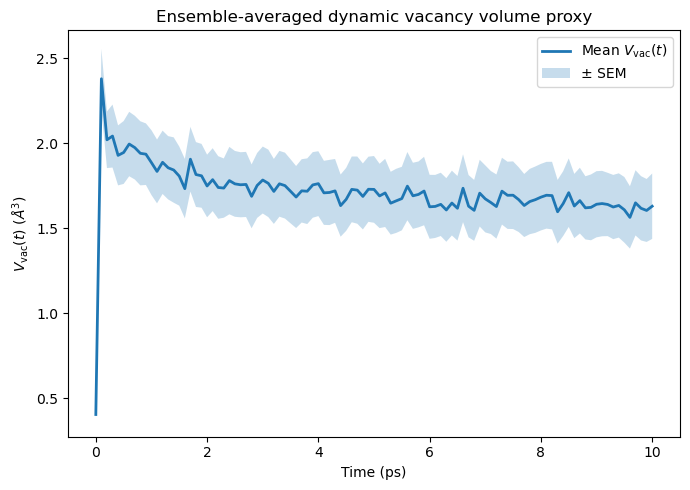

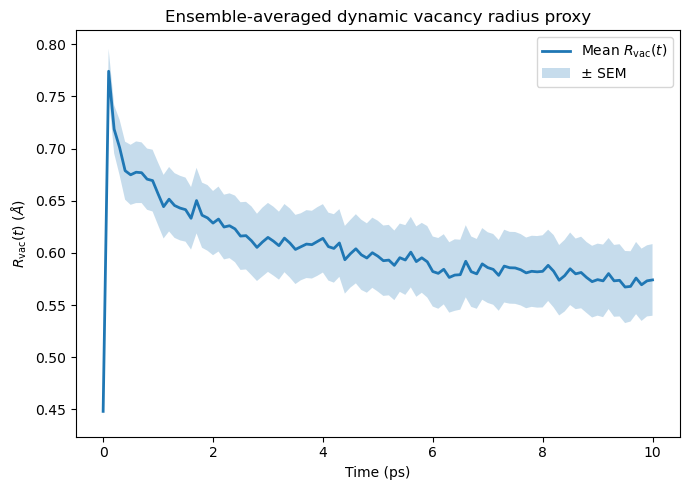

In [7]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Settings
# ============================================================
TRAJ_PATTERN = "traj_E*.lammpstrj"

TYPE_AL      = 1
TYPE_O       = 2
TYPE_OI      = 3
TYPE_CORE_AL = 4

# ---------- ballooning settings ----------
ROI_RADIUS   = 1.0   # Å
GRID_SPACING = 0.05  # Å

# !!! Fill with your own excluded radii definition !!!
R_EXCL_AL = 1.0
R_EXCL_O  = 1.0

TIMESTEP_PS = 0.001
OUTPUT_DIR = "ov_dynamic_ballooning"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# Utilities
# ============================================================
def minimum_image(vec, box):
    return vec - box * np.round(vec / box)


def parse_lammpstrj(filename):
    """
    Parse LAMMPS custom dump:
    ITEM: TIMESTEP
    ITEM: NUMBER OF ATOMS
    ITEM: BOX BOUNDS ...
    ITEM: ATOMS id type q x y z
    """
    frames = []

    with open(filename, "r") as f:
        lines = f.readlines()

    i = 0
    nlines = len(lines)

    while i < nlines:
        if not lines[i].startswith("ITEM: TIMESTEP"):
            i += 1
            continue

        step = int(lines[i + 1].strip())
        natoms = int(lines[i + 3].strip())

        xlo, xhi = map(float, lines[i + 5].split()[:2])
        ylo, yhi = map(float, lines[i + 6].split()[:2])
        zlo, zhi = map(float, lines[i + 7].split()[:2])
        box = np.array([xhi - xlo, yhi - ylo, zhi - zlo], dtype=float)

        atom_header = lines[i + 8].strip()
        cols = atom_header.split()[2:]
        col_index = {c: idx for idx, c in enumerate(cols)}

        atom_block = lines[i + 9:i + 9 + natoms]
        data = np.array([row.split() for row in atom_block], dtype=float)

        ids = data[:, col_index["id"]].astype(int)
        types = data[:, col_index["type"]].astype(int)
        coords = np.column_stack([
            data[:, col_index["x"]],
            data[:, col_index["y"]],
            data[:, col_index["z"]],
        ])

        frames.append({
            "step": step,
            "time_ps": step * TIMESTEP_PS,
            "box": box,
            "ids": ids,
            "types": types,
            "coords": coords,
        })

        i = i + 9 + natoms

    return frames


def make_roi_grid(center, roi_radius, spacing):
    """
    Generate a cubic grid and keep only points inside the spherical ROI
    """
    offsets = np.arange(-roi_radius, roi_radius + 0.5 * spacing, spacing)
    pts = []
    for dx in offsets:
        for dy in offsets:
            for dz in offsets:
                if dx*dx + dy*dy + dz*dz <= roi_radius*roi_radius:
                    pts.append(center + np.array([dx, dy, dz], dtype=float))
    return np.asarray(pts, dtype=float)


def get_excluded_radii(types):
    """
    Map atom types to excluded radii
    """
    r = np.zeros_like(types, dtype=float)
    r[np.isin(types, [TYPE_AL, TYPE_CORE_AL])] = R_EXCL_AL
    r[np.isin(types, [TYPE_O, TYPE_OI])]       = R_EXCL_O
    return r


def vacancy_volume_for_frame(pos, types, box):
    """
    Compute dynamic V_vac(t) for one frame using the same ballooning metric
    as your static code.
    """
    # ---- Ov-core Al set ----
    core_idx = np.where(types == TYPE_CORE_AL)[0]
    if len(core_idx) != 3:
        raise RuntimeError(f"Expected 3 Ov-core Al atoms, got {len(core_idx)}")

    core_pos = pos[core_idx]

    # ---- geometric centroid of Ov-core Al ----
    # unwrap core positions relative to the first core Al before centroid
    ref = core_pos[0]
    core_unwrapped = ref + minimum_image(core_pos - ref, box)
    r_c = core_unwrapped.mean(axis=0)

    # ---- ROI grid ----
    grid_points = make_roi_grid(r_c, ROI_RADIUS, GRID_SPACING)

    # ---- all atoms + excluded radii ----
    atom_radii = get_excluded_radii(types)

    V_list = []
    R_list = []

    for g in grid_points:
        disp = minimum_image(pos - g, box)
        d = np.linalg.norm(disp, axis=1)

        # largest non-overlapping probe radius at this point
        Rk = np.min(d - atom_radii)

        if Rk > 0:
            Vk = (4.0 / 3.0) * np.pi * Rk**3
            R_list.append(Rk)
            V_list.append(Vk)

    if len(V_list) == 0:
        raise RuntimeError("No valid probe spheres found inside ROI. Check excluded radii / ROI settings.")

    V_list = np.asarray(V_list, dtype=float)
    R_list = np.asarray(R_list, dtype=float)

    V_vac = np.median(V_list)
    R_vac = np.median(R_list)

    return V_vac, R_vac, r_c, len(V_list)


# ============================================================
# Main loop over trajectories
# ============================================================
files = sorted(glob.glob(TRAJ_PATTERN))
if not files:
    raise RuntimeError(f"No files matched pattern: {TRAJ_PATTERN}")

all_event_series = []
common_times = None

print("=== Dynamic Ov vacancy volume analysis ===")
for f in files:
    event_name = os.path.splitext(os.path.basename(f))[0]
    print(f"Processing {event_name} ...")

    frames = parse_lammpstrj(f)

    rows = []
    for fr in frames:
        V_vac, R_vac, r_c, n_valid = vacancy_volume_for_frame(fr["coords"], fr["types"], fr["box"])
        rows.append({
            "event": event_name,
            "step": fr["step"],
            "time_ps": fr["time_ps"],
            "V_vac_A3": V_vac,
            "R_vac_A": R_vac,
            "center_x": r_c[0],
            "center_y": r_c[1],
            "center_z": r_c[2],
            "n_valid_grid_points": n_valid
        })

    df_event = pd.DataFrame(rows)
    df_event.to_csv(os.path.join(OUTPUT_DIR, f"{event_name}_dynamic_vacancy_volume.csv"), index=False)
    all_event_series.append(df_event)

    times = df_event["time_ps"].to_numpy()
    if common_times is None:
        common_times = times
    else:
        if len(times) != len(common_times) or not np.allclose(times, common_times):
            raise RuntimeError(f"Time grid mismatch in {event_name}")

# ============================================================
# Ensemble averages
# ============================================================
df_all = pd.concat(all_event_series, ignore_index=True)

df_avg = (
    df_all.groupby("time_ps")[["V_vac_A3", "R_vac_A"]]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# flatten multi-index columns
df_avg.columns = [
    "time_ps",
    "V_mean", "V_std", "V_count",
    "R_mean", "R_std", "R_count"
]

df_avg["V_sem"] = df_avg["V_std"] / np.sqrt(df_avg["V_count"])
df_avg["R_sem"] = df_avg["R_std"] / np.sqrt(df_avg["R_count"])

df_all.to_csv(os.path.join(OUTPUT_DIR, "all_events_dynamic_vacancy_volume_long.csv"), index=False)
df_avg.to_csv(os.path.join(OUTPUT_DIR, "dynamic_vacancy_volume_avg_vs_time.csv"), index=False)

print("\n=== Ensemble summary written ===")
print(os.path.join(OUTPUT_DIR, "dynamic_vacancy_volume_avg_vs_time.csv"))

# ============================================================
# Plot: average V_vac(t)
# ============================================================
plt.figure(figsize=(7, 5))
plt.plot(df_avg["time_ps"], df_avg["V_mean"], linewidth=2, label=r"Mean $V_{\mathrm{vac}}(t)$")
plt.fill_between(
    df_avg["time_ps"],
    df_avg["V_mean"] - df_avg["V_sem"],
    df_avg["V_mean"] + df_avg["V_sem"],
    alpha=0.25,
    label="± SEM"
)
plt.xlabel("Time (ps)")
plt.ylabel(r"$V_{\mathrm{vac}}(t)$ ($\AA^3$)")
plt.title(r"Ensemble-averaged dynamic vacancy volume proxy")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "dynamic_vacancy_volume_avg_vs_time.png"), dpi=300)
plt.show()

# ============================================================
# Optional: average R_vac(t)
# ============================================================
plt.figure(figsize=(7, 5))
plt.plot(df_avg["time_ps"], df_avg["R_mean"], linewidth=2, label=r"Mean $R_{\mathrm{vac}}(t)$")
plt.fill_between(
    df_avg["time_ps"],
    df_avg["R_mean"] - df_avg["R_sem"],
    df_avg["R_mean"] + df_avg["R_sem"],
    alpha=0.25,
    label="± SEM"
)
plt.xlabel("Time (ps)")
plt.ylabel(r"$R_{\mathrm{vac}}(t)$ ($\AA$)")
plt.title(r"Ensemble-averaged dynamic vacancy radius proxy")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "dynamic_vacancy_radius_avg_vs_time.png"), dpi=300)
plt.show()

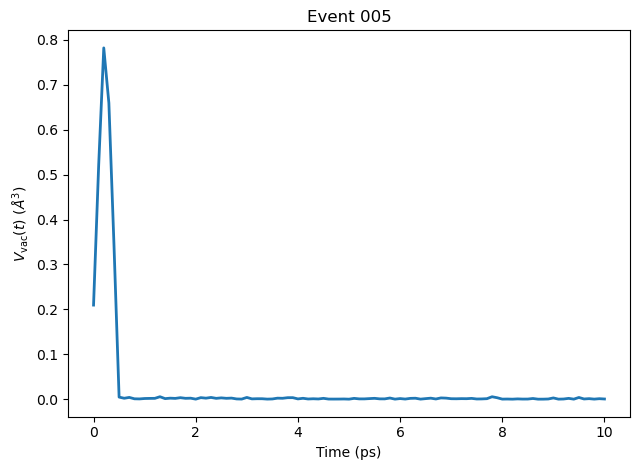

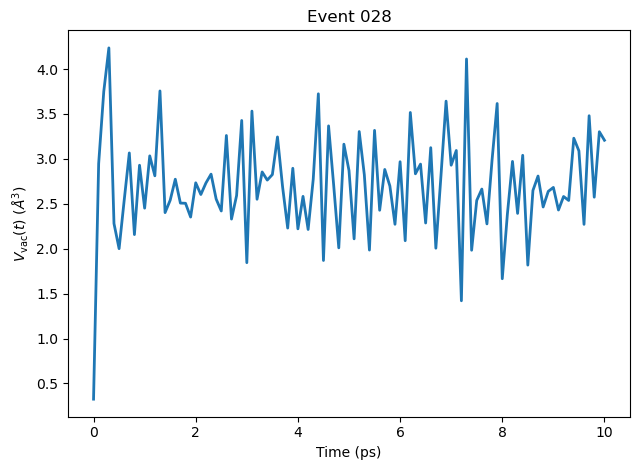

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================
files = {
    "Event 005": "ov_dynamic_ballooning/traj_E005_dynamic_vacancy_volume.csv",
    "Event 028": "ov_dynamic_ballooning/traj_E028_dynamic_vacancy_volume.csv",
}

# =========================
# Plot each event separately
# =========================
for label, path in files.items():
    df = pd.read_csv(path)

    plt.figure(figsize=(6.5, 4.8))
    plt.plot(df["time_ps"], df["V_vac_A3"], linewidth=2)

    plt.xlabel("Time (ps)")
    plt.ylabel(r"$V_{\mathrm{vac}}(t)$ ($\AA^3$)")
    plt.title(label)
    plt.tight_layout()

    outname = label.lower().replace(" ", "_") + "_Vvac_vs_time.png"
    plt.savefig(outname, dpi=300)
    plt.show()

In [3]:
import os
import glob
import numpy as np
import pandas as pd

# ============================================================
# User settings
# ============================================================
TRAJ_PATTERN = "traj_E*.lammpstrj"

TYPE_AL      = 1
TYPE_O       = 2
TYPE_OI      = 3
TYPE_CORE_AL = 4

AL_TYPES = {TYPE_AL, TYPE_CORE_AL}
O_TYPES  = {TYPE_O, TYPE_OI}

RCUT_ALO = 2.325

# ---------- ballooning settings ----------
ROI_RADIUS   = 1.0
GRID_SPACING = 0.10   # faster than 0.05
R_EXCL_AL    = 1.0
R_EXCL_O     = 1.0

TOPK_FOR_VOID = 20

OUTPUT_CSV = "stable_void_triplet_ranks_fast.csv"

JUMPBACK_EVENTS = {2, 4, 5, 8, 17, 25, 26, 30, 32, 37, 57, 60, 67, 75, 76, 77, 78, 91, 98, 100}


# ============================================================
# Utilities
# ============================================================
def minimum_image(vec, box):
    return vec - box * np.round(vec / box)


def parse_lammpstrj(filename):
    frames = []

    with open(filename, "r") as f:
        lines = f.readlines()

    i = 0
    nlines = len(lines)

    while i < nlines:
        if not lines[i].startswith("ITEM: TIMESTEP"):
            i += 1
            continue

        step = int(lines[i + 1].strip())
        natoms = int(lines[i + 3].strip())

        xlo, xhi = map(float, lines[i + 5].split()[:2])
        ylo, yhi = map(float, lines[i + 6].split()[:2])
        zlo, zhi = map(float, lines[i + 7].split()[:2])
        box = np.array([xhi - xlo, yhi - ylo, zhi - zlo], dtype=float)

        atom_header = lines[i + 8].strip()
        cols = atom_header.split()[2:]
        col_index = {c: idx for idx, c in enumerate(cols)}

        atom_block = lines[i + 9:i + 9 + natoms]
        data = np.array([row.split() for row in atom_block], dtype=float)

        ids = data[:, col_index["id"]].astype(int)
        types = data[:, col_index["type"]].astype(int)
        coords = np.column_stack([
            data[:, col_index["x"]],
            data[:, col_index["y"]],
            data[:, col_index["z"]],
        ])

        frames.append({
            "step": step,
            "box": box,
            "ids": ids,
            "types": types,
            "coords": coords,
        })

        i = i + 9 + natoms

    return frames


def make_roi_grid(center, roi_radius, spacing):
    offsets = np.arange(-roi_radius, roi_radius + 0.5 * spacing, spacing)
    pts = []
    for dx in offsets:
        for dy in offsets:
            for dz in offsets:
                if dx*dx + dy*dy + dz*dz <= roi_radius*roi_radius:
                    pts.append(center + np.array([dx, dy, dz], dtype=float))
    return np.asarray(pts, dtype=float)


def get_excluded_radii(types):
    r = np.zeros_like(types, dtype=float)
    r[np.isin(types, [TYPE_AL, TYPE_CORE_AL])] = R_EXCL_AL
    r[np.isin(types, [TYPE_O, TYPE_OI])]       = R_EXCL_O
    return r


def ballooning_void_volume_at_center(center, pos, types, box):
    grid_points = make_roi_grid(center, ROI_RADIUS, GRID_SPACING)
    atom_radii = get_excluded_radii(types)

    V_list = []
    for g in grid_points:
        disp = minimum_image(pos - g, box)
        d = np.linalg.norm(disp, axis=1)
        Rk = np.min(d - atom_radii)
        if Rk > 0:
            V_list.append((4.0 / 3.0) * np.pi * Rk**3)

    if len(V_list) == 0:
        return np.nan
    return float(np.median(V_list))


def compute_all_al_cn(pos, types, box, rcut=RCUT_ALO):
    al_idx = np.where(np.isin(types, list(AL_TYPES)))[0]
    o_idx = np.where(np.isin(types, list(O_TYPES)))[0]

    al_pos = pos[al_idx]
    o_pos = pos[o_idx]

    cn_map = {}
    for idx_global, p in zip(al_idx, al_pos):
        delta = o_pos - p
        delta_mic = minimum_image(delta, box)
        dist = np.linalg.norm(delta_mic, axis=1)
        cn_map[idx_global] = int(np.sum(dist <= rcut))
    return al_idx, cn_map


def triplet_centroid(pos_triplet, box):
    ref = pos_triplet[0]
    unwrapped = ref + minimum_image(pos_triplet - ref, box)
    return unwrapped.mean(axis=0)


def build_unique_triplets(ids, types, pos, box):
    al_idx = np.where(np.isin(types, list(AL_TYPES)))[0]
    al_ids = ids[al_idx]
    al_pos = pos[al_idx]

    triplet_keys = set()
    triplets = []

    for i_local, i_global in enumerate(al_idx):
        ref_pos = pos[i_global]
        others_local = [j for j in range(len(al_idx)) if j != i_local]
        delta = al_pos[others_local] - ref_pos
        delta_mic = minimum_image(delta, box)
        dist = np.linalg.norm(delta_mic, axis=1)

        if len(dist) < 2:
            continue

        nearest_two_local = np.argsort(dist)[:2]
        nn_globals = [al_idx[others_local[k]] for k in nearest_two_local]

        triplet_ids = tuple(sorted(ids[[i_global] + nn_globals].tolist()))
        if triplet_ids not in triplet_keys:
            triplet_keys.add(triplet_ids)
            triplets.append(triplet_ids)

    return triplets


def triplet_ids_to_indices(triplet_ids, ids):
    id_to_idx = {aid: idx for idx, aid in enumerate(ids)}
    return [id_to_idx[aid] for aid in triplet_ids]


def zscore_safe(x, mu, sigma, direction="high"):
    if sigma <= 1e-12:
        return 0.0
    if direction == "high":
        return (x - mu) / sigma
    if direction == "low":
        return (mu - x) / sigma
    raise ValueError


# ============================================================
# Main
# ============================================================
traj_files = sorted(glob.glob(TRAJ_PATTERN))
rows = []

for traj_file in traj_files:
    basename = os.path.basename(traj_file)
    import re
    m = re.search(r"E(\d+)", basename)
    if not m:
        print(f"Skipping {basename}: cannot parse event id")
        continue
    event_id = int(m.group(1))

    if event_id in JUMPBACK_EVENTS:
        continue

    print(f"Processing stable-void event {event_id:03d} ...")

    fr = parse_lammpstrj(traj_file)[-1]
    ids, types, pos, box = fr["ids"], fr["types"], fr["coords"], fr["box"]

    core_idx = np.where(types == TYPE_CORE_AL)[0]
    if len(core_idx) != 3:
        print(f"  skipped: expected 3 type-4 atoms, got {len(core_idx)}")
        continue

    true_triplet_ids = tuple(sorted(ids[core_idx].tolist()))

    # all candidate triplets
    candidate_triplets = build_unique_triplets(ids, types, pos, box)
    if true_triplet_ids not in candidate_triplets:
        candidate_triplets.append(true_triplet_ids)

    # precompute all Al CNs
    _, cn_map = compute_all_al_cn(pos, types, box)

    # phase 1: CN for all triplets
    data = []
    for triplet_ids in candidate_triplets:
        triplet_idx = triplet_ids_to_indices(triplet_ids, ids)
        cn_mean = float(np.mean([cn_map[idx] for idx in triplet_idx]))
        data.append({
            "triplet_ids": triplet_ids,
            "cn_mean": cn_mean,
            "is_true_ovcore": int(triplet_ids == true_triplet_ids)
        })

    df = pd.DataFrame(data)

    # background for CN
    df_bg = df[df["is_true_ovcore"] == 0].copy()
    mu_cn = df_bg["cn_mean"].mean()
    sd_cn = df_bg["cn_mean"].std(ddof=1)

    df["score_cn"] = df["cn_mean"].apply(lambda x: zscore_safe(x, mu_cn, sd_cn, direction="low"))
    df["rank_cn_all"] = df["score_cn"].rank(method="min", ascending=False).astype(int)

    # keep only top-K by CN score for expensive void calculation
    df_top = df.sort_values("score_cn", ascending=False).head(TOPK_FOR_VOID).copy()

    # ensure true triplet included
    if not (df_top["is_true_ovcore"] == 1).any():
        df_true = df[df["is_true_ovcore"] == 1].copy()
        df_top = pd.concat([df_top, df_true], ignore_index=True).drop_duplicates(subset=["triplet_ids"])

    # phase 2: void only for top-K
    void_vals = []
    for _, row in df_top.iterrows():
        triplet_ids = row["triplet_ids"]
        triplet_idx = triplet_ids_to_indices(triplet_ids, ids)
        ctr = triplet_centroid(pos[triplet_idx], box)
        void_vol = ballooning_void_volume_at_center(ctr, pos, types, box)
        void_vals.append(void_vol)

    df_top["void_vol"] = void_vals

    df_top_bg = df_top[df_top["is_true_ovcore"] == 0].copy()
    mu_v = df_top_bg["void_vol"].mean()
    sd_v = df_top_bg["void_vol"].std(ddof=1)

    df_top["score_void"] = df_top["void_vol"].apply(lambda x: zscore_safe(x, mu_v, sd_v, direction="high"))
    df_top["score_total"] = df_top["score_cn"] + df_top["score_void"]

    df_top["rank_void_topK"] = df_top["score_void"].rank(method="min", ascending=False).astype(int)
    df_top["rank_total_topK"] = df_top["score_total"].rank(method="min", ascending=False).astype(int)

    row_true_all = df[df["is_true_ovcore"] == 1].iloc[0]
    row_true_top = df_top[df_top["is_true_ovcore"] == 1].iloc[0]

    rows.append({
        "event_id": event_id,
        "true_triplet_ids": ";".join(map(str, true_triplet_ids)),
        "n_candidate_triplets_all": len(df),
        "n_triplets_void_topK": len(df_top),
        "cn_mean_true": row_true_all["cn_mean"],
        "score_cn_true": row_true_all["score_cn"],
        "rank_cn_all": int(row_true_all["rank_cn_all"]),
        "void_vol_true": row_true_top["void_vol"],
        "score_void_true": row_true_top["score_void"],
        "rank_void_topK": int(row_true_top["rank_void_topK"]),
        "score_total_true": row_true_top["score_total"],
        "rank_total_topK": int(row_true_top["rank_total_topK"]),
    })

df_out = pd.DataFrame(rows).sort_values("event_id")
df_out.to_csv(OUTPUT_CSV, index=False)

print(f"\nSaved: {OUTPUT_CSV}")
if len(df_out) > 0:
    print("\nSummary")
    print("CN rank #1 (all triplets):", int((df_out["rank_cn_all"] == 1).sum()), "/", len(df_out))
    print("Void rank #1 (topK only):", int((df_out["rank_void_topK"] == 1).sum()), "/", len(df_out))
    print("Total rank #1 (topK only):", int((df_out["rank_total_topK"] == 1).sum()), "/", len(df_out))
    print(df_out.head())

Processing stable-void event 001 ...
Processing stable-void event 003 ...
Processing stable-void event 006 ...
Processing stable-void event 007 ...
Processing stable-void event 009 ...
Processing stable-void event 010 ...
Processing stable-void event 011 ...
Processing stable-void event 012 ...
Processing stable-void event 013 ...
Processing stable-void event 014 ...
Processing stable-void event 015 ...
Processing stable-void event 016 ...
Processing stable-void event 018 ...
Processing stable-void event 019 ...
Processing stable-void event 020 ...
Processing stable-void event 021 ...
Processing stable-void event 022 ...
Processing stable-void event 023 ...
Processing stable-void event 024 ...
Processing stable-void event 027 ...
Processing stable-void event 028 ...
Processing stable-void event 029 ...
Processing stable-void event 031 ...
Processing stable-void event 033 ...
Processing stable-void event 034 ...
Processing stable-void event 035 ...
Processing stable-void event 036 ...
P

In [6]:
import os
import glob
import re
import numpy as np
import pandas as pd

# ============================================================
# User settings
# ============================================================
TRAJ_PATTERN = "traj_E*.lammpstrj"

TYPE_AL      = 1
TYPE_O       = 2
TYPE_OI      = 3
TYPE_CORE_AL = 4

AL_TYPES = {TYPE_AL, TYPE_CORE_AL}
O_TYPES  = {TYPE_O, TYPE_OI}

RCUT_ALO = 2.325

# ---------- ballooning settings ----------
ROI_RADIUS   = 1.0
GRID_SPACING = 0.10
R_EXCL_AL    = 1.0   # fill with your chosen excluded radius
R_EXCL_O     = 1.0   # fill with your chosen excluded radius

TOPK_CN = 20
LAST_WINDOW_PS = 1.0   # use the last 1 ps

OUTPUT_SUMMARY_CSV = "stable_void_identifiability_summary_last1ps_top20.csv"
OUTPUT_DETAIL_CSV  = "stable_void_identifiability_candidates_last1ps_top20_long.csv"

# jump-back events to exclude
JUMPBACK_EVENTS = {2, 4, 5, 8, 17, 25, 26, 30, 32, 37, 57, 60, 67, 75, 76, 77, 78, 91, 98, 100}


# ============================================================
# Utilities
# ============================================================
def minimum_image(vec, box):
    return vec - box * np.round(vec / box)


def parse_lammpstrj(filename):
    frames = []
    with open(filename, "r") as f:
        lines = f.readlines()

    i = 0
    nlines = len(lines)

    while i < nlines:
        if not lines[i].startswith("ITEM: TIMESTEP"):
            i += 1
            continue

        step = int(lines[i + 1].strip())
        natoms = int(lines[i + 3].strip())

        xlo, xhi = map(float, lines[i + 5].split()[:2])
        ylo, yhi = map(float, lines[i + 6].split()[:2])
        zlo, zhi = map(float, lines[i + 7].split()[:2])
        box = np.array([xhi - xlo, yhi - ylo, zhi - zlo], dtype=float)

        atom_header = lines[i + 8].strip()
        cols = atom_header.split()[2:]
        col_index = {c: idx for idx, c in enumerate(cols)}

        atom_block = lines[i + 9:i + 9 + natoms]
        data = np.array([row.split() for row in atom_block], dtype=float)

        ids = data[:, col_index["id"]].astype(int)
        types = data[:, col_index["type"]].astype(int)
        coords = np.column_stack([
            data[:, col_index["x"]],
            data[:, col_index["y"]],
            data[:, col_index["z"]],
        ])

        frames.append({
            "step": step,
            "time_ps": step * 0.001,   # metal units: 0.001 ps per step
            "box": box,
            "ids": ids,
            "types": types,
            "coords": coords,
        })

        i = i + 9 + natoms

    return frames


def make_roi_grid(center, roi_radius, spacing):
    offsets = np.arange(-roi_radius, roi_radius + 0.5 * spacing, spacing)
    pts = []
    for dx in offsets:
        for dy in offsets:
            for dz in offsets:
                if dx*dx + dy*dy + dz*dz <= roi_radius * roi_radius:
                    pts.append(center + np.array([dx, dy, dz], dtype=float))
    return np.asarray(pts, dtype=float)


def get_excluded_radii(types):
    r = np.zeros_like(types, dtype=float)
    r[np.isin(types, [TYPE_AL, TYPE_CORE_AL])] = R_EXCL_AL
    r[np.isin(types, [TYPE_O, TYPE_OI])] = R_EXCL_O
    return r


def ballooning_void_median_at_center(center, pos, types, box):
    """
    Return only the median probe volume in the ROI.
    Faster than returning the full ROI distribution stats.
    """
    grid_points = make_roi_grid(center, ROI_RADIUS, GRID_SPACING)
    atom_radii = get_excluded_radii(types)

    V_list = []
    for g in grid_points:
        disp = minimum_image(pos - g, box)
        d = np.linalg.norm(disp, axis=1)
        Rk = np.min(d - atom_radii)
        if Rk > 0:
            Vk = (4.0 / 3.0) * np.pi * Rk**3
            V_list.append(Vk)

    if len(V_list) == 0:
        return np.nan
    return float(np.median(V_list))


def compute_all_al_cn(pos, types, box, rcut=RCUT_ALO):
    al_idx = np.where(np.isin(types, list(AL_TYPES)))[0]
    o_idx = np.where(np.isin(types, list(O_TYPES)))[0]

    al_pos = pos[al_idx]
    o_pos = pos[o_idx]

    cn_map = {}
    for idx_global, p in zip(al_idx, al_pos):
        delta = o_pos - p
        delta_mic = minimum_image(delta, box)
        dist = np.linalg.norm(delta_mic, axis=1)
        cn_map[idx_global] = int(np.sum(dist <= rcut))
    return cn_map


def triplet_centroid(pos_triplet, box):
    ref = pos_triplet[0]
    unwrapped = ref + minimum_image(pos_triplet - ref, box)
    return unwrapped.mean(axis=0)


def build_unique_triplets(ids, types, pos, box):
    """
    For each Al atom, take its two nearest Al neighbours.
    Deduplicate by sorted triplet atom IDs.
    """
    al_idx = np.where(np.isin(types, list(AL_TYPES)))[0]
    al_pos = pos[al_idx]

    triplet_keys = set()
    triplets = []

    for i_local, i_global in enumerate(al_idx):
        ref_pos = pos[i_global]
        others_local = [j for j in range(len(al_idx)) if j != i_local]
        if len(others_local) < 2:
            continue

        delta = al_pos[others_local] - ref_pos
        delta_mic = minimum_image(delta, box)
        dist = np.linalg.norm(delta_mic, axis=1)

        nearest_two_local = np.argsort(dist)[:2]
        nn_globals = [al_idx[others_local[k]] for k in nearest_two_local]

        triplet_ids = tuple(sorted(ids[[i_global] + nn_globals].tolist()))
        if triplet_ids not in triplet_keys:
            triplet_keys.add(triplet_ids)
            triplets.append(triplet_ids)

    return triplets


def triplet_ids_to_indices(triplet_ids, ids):
    id_to_idx = {aid: idx for idx, aid in enumerate(ids)}
    return [id_to_idx[aid] for aid in triplet_ids]


def intervals_overlap(a_mean, a_std, b_mean, b_std):
    a_lo, a_hi = a_mean - a_std, a_mean + a_std
    b_lo, b_hi = b_mean - b_std, b_mean + b_std
    return max(a_lo, b_lo) <= min(a_hi, b_hi)


# ============================================================
# Main
# ============================================================
traj_files = sorted(glob.glob(TRAJ_PATTERN))
if not traj_files:
    raise RuntimeError(f"No files matched pattern: {TRAJ_PATTERN}")

summary_rows = []
detail_rows = []

for traj_file in traj_files:
    basename = os.path.basename(traj_file)
    m = re.search(r"E(\d+)", basename)
    if not m:
        print(f"Skipping {basename}: cannot parse event id")
        continue

    event_id = int(m.group(1))
    if event_id in JUMPBACK_EVENTS:
        continue

    print(f"Processing stable-void event {event_id:03d} ...")

    frames = parse_lammpstrj(traj_file)
    if len(frames) == 0:
        print("  skipped: empty trajectory")
        continue

    # -------- final frame for CN coarse filter --------
    fr_final = frames[-1]
    ids = fr_final["ids"]
    types = fr_final["types"]
    pos = fr_final["coords"]
    box = fr_final["box"]

    core_idx = np.where(types == TYPE_CORE_AL)[0]
    if len(core_idx) != 3:
        print(f"  skipped: expected 3 type-4 atoms, got {len(core_idx)}")
        continue

    true_triplet_ids = tuple(sorted(ids[core_idx].tolist()))

    candidate_triplets = build_unique_triplets(ids, types, pos, box)
    if true_triplet_ids not in candidate_triplets:
        candidate_triplets.append(true_triplet_ids)

    cn_map = compute_all_al_cn(pos, types, box)

    triplet_data = []
    for triplet_ids in candidate_triplets:
        triplet_idx = triplet_ids_to_indices(triplet_ids, ids)
        cn_mean = float(np.mean([cn_map[idx] for idx in triplet_idx]))
        triplet_data.append({
            "triplet_ids": triplet_ids,
            "cn_mean": cn_mean,
            "is_true_ovcore": int(triplet_ids == true_triplet_ids)
        })

    df = pd.DataFrame(triplet_data)

    true_cn = float(df.loc[df["is_true_ovcore"] == 1, "cn_mean"].iloc[0])
    df["cn_absdiff_to_true"] = np.abs(df["cn_mean"] - true_cn)

    # permissive CN-compatible candidate set
    df_top = df.sort_values("cn_absdiff_to_true", ascending=True).head(TOPK_CN).copy()

    if not (df_top["is_true_ovcore"] == 1).any():
        df_true = df[df["is_true_ovcore"] == 1].copy()
        df_top = pd.concat([df_top, df_true], ignore_index=True).drop_duplicates(subset=["triplet_ids"])

    # -------- last 1 ps window --------
    tmax = frames[-1]["time_ps"]
    tmin = tmax - LAST_WINDOW_PS
    frames_window = [fr for fr in frames if fr["time_ps"] >= tmin]

    if len(frames_window) == 0:
        print("  skipped: no frames in last window")
        continue

    # -------- void time series for CN-compatible top20 --------
    for idx_row, row in df_top.iterrows():
        triplet_ids = row["triplet_ids"]
        v_series = []

        for fr in frames_window:
            ids_t = fr["ids"]
            types_t = fr["types"]
            pos_t = fr["coords"]
            box_t = fr["box"]

            triplet_idx_t = triplet_ids_to_indices(triplet_ids, ids_t)
            ctr_t = triplet_centroid(pos_t[triplet_idx_t], box_t)
            v_t = ballooning_void_median_at_center(ctr_t, pos_t, types_t, box_t)
            v_series.append(v_t)

        v_series = np.asarray(v_series, dtype=float)
        v_mean = float(np.nanmean(v_series))
        if np.sum(np.isfinite(v_series)) > 1:
            v_std = float(np.nanstd(v_series, ddof=1))
        else:
            v_std = 0.0

        df_top.loc[idx_row, "void_mean_time"] = v_mean
        df_top.loc[idx_row, "void_std_time"] = v_std
        df_top.loc[idx_row, "n_frames_window"] = len(v_series)

    # -------- overlap against true Ov-core --------
    row_true = df_top[df_top["is_true_ovcore"] == 1].iloc[0]
    true_v_mean = float(row_true["void_mean_time"])
    true_v_std = float(row_true["void_std_time"])

    overlap_flags = []
    for _, row in df_top.iterrows():
        overlap = intervals_overlap(
            true_v_mean, true_v_std,
            float(row["void_mean_time"]), float(row["void_std_time"])
        )
        overlap_flags.append(int(overlap))

    df_top["void_overlaps_true_timewindow"] = overlap_flags

    n_overlap_total = int(df_top["void_overlaps_true_timewindow"].sum())
    n_overlap_other = int(df_top.loc[df_top["is_true_ovcore"] == 0, "void_overlaps_true_timewindow"].sum())
    is_unique = (n_overlap_other == 0)

    df_top["cn_rank_in_topK"] = df_top["cn_absdiff_to_true"].rank(method="min", ascending=True).astype(int)

    # -------- save detail rows --------
    for _, row in df_top.iterrows():
        detail_rows.append({
            "event_id": event_id,
            "triplet_ids": ";".join(map(str, row["triplet_ids"])),
            "is_true_ovcore": int(row["is_true_ovcore"]),
            "cn_mean": row["cn_mean"],
            "cn_absdiff_to_true": row["cn_absdiff_to_true"],
            "cn_rank_in_topK": int(row["cn_rank_in_topK"]),
            "void_mean_time": row["void_mean_time"],
            "void_std_time": row["void_std_time"],
            "n_frames_window": int(row["n_frames_window"]),
            "void_overlaps_true_timewindow": int(row["void_overlaps_true_timewindow"]),
        })

    summary_rows.append({
        "event_id": event_id,
        "true_triplet_ids": ";".join(map(str, true_triplet_ids)),
        "n_candidate_triplets_all": len(df),
        "n_cn_compatible_triplets": len(df_top),
        "window_tmin_ps": tmin,
        "window_tmax_ps": tmax,
        "n_frames_window": len(frames_window),
        "true_cn_mean": true_cn,
        "true_void_mean_time": true_v_mean,
        "true_void_std_time": true_v_std,
        "n_overlap_total_in_topK_timewindow": n_overlap_total,
        "n_overlap_other_in_topK_timewindow": n_overlap_other,
        "is_unique_in_topK_timewindow": int(is_unique),
    })

# ============================================================
# Save
# ============================================================
df_summary = pd.DataFrame(summary_rows).sort_values("event_id")
df_detail = pd.DataFrame(detail_rows).sort_values(
    ["event_id", "is_true_ovcore", "cn_absdiff_to_true"],
    ascending=[True, False, True]
)

df_summary.to_csv(OUTPUT_SUMMARY_CSV, index=False)
df_detail.to_csv(OUTPUT_DETAIL_CSV, index=False)

print(f"\nSaved summary: {OUTPUT_SUMMARY_CSV}")
print(f"Saved details: {OUTPUT_DETAIL_CSV}")

if len(df_summary) > 0:
    n_events = len(df_summary)
    n_unique = int(df_summary["is_unique_in_topK_timewindow"].sum())
    print("\nSummary")
    print(f"Unique in CN-top{TOPK_CN} over last {LAST_WINDOW_PS:.1f} ps: {n_unique} / {n_events}")
    print("Head of summary table:")
    print(df_summary.head())

Processing stable-void event 001 ...
Processing stable-void event 003 ...
Processing stable-void event 006 ...
Processing stable-void event 007 ...
Processing stable-void event 009 ...
Processing stable-void event 010 ...
Processing stable-void event 011 ...
Processing stable-void event 012 ...
Processing stable-void event 013 ...
Processing stable-void event 014 ...
Processing stable-void event 015 ...
Processing stable-void event 016 ...
Processing stable-void event 018 ...
Processing stable-void event 019 ...
Processing stable-void event 020 ...
Processing stable-void event 021 ...
Processing stable-void event 022 ...
Processing stable-void event 023 ...
Processing stable-void event 024 ...
Processing stable-void event 027 ...
Processing stable-void event 028 ...
Processing stable-void event 029 ...
Processing stable-void event 031 ...
Processing stable-void event 033 ...
Processing stable-void event 034 ...
Processing stable-void event 035 ...
Processing stable-void event 036 ...
P

========== Basic summary ==========
Total stable-void events: 80
Unique events:            70
Non-unique events:        10
Unique fraction:          0.875

========== Non-unique events ==========
 event_id  n_overlap_other_in_topK_timewindow  true_void_mean_time  true_void_std_time
       41                                  10             0.067408            0.031296
       40                                   8             0.053159            0.020525
       47                                   6             0.041514            0.008426
       83                                   5             0.080892            0.017039
       94                                   4             0.107736            0.017326
       31                                   3             0.159456            0.048992
       59                                   2             0.078178            0.014284
       33                                   2             0.087603            0.035273
       82            

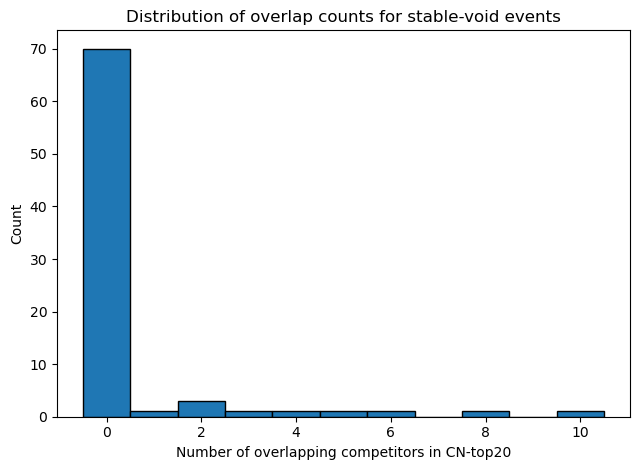

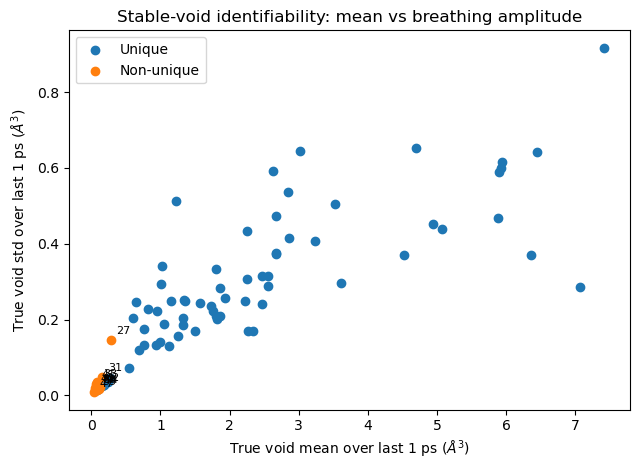

C:\Users\zilie\AppData\Local\Temp\ipykernel_26720\1774227281.py:151: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
C:\Users\zilie\AppData\Local\Temp\ipykernel_26720\1774227281.py:158: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


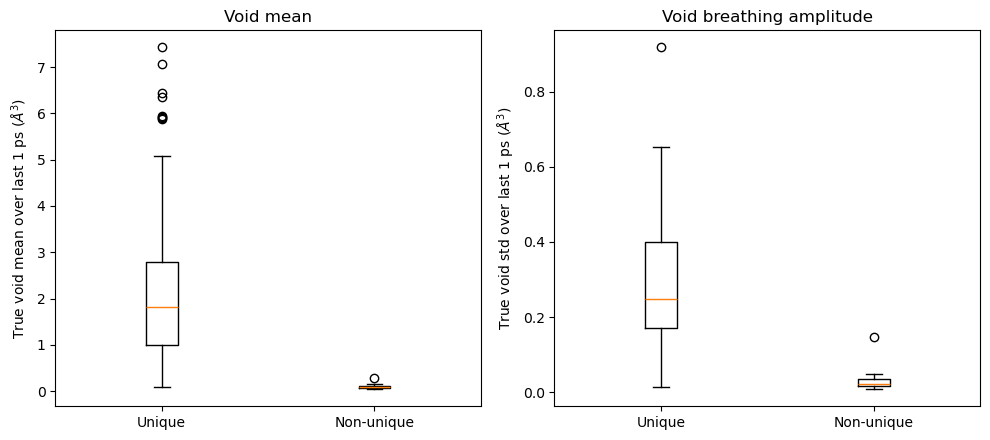

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Input files
# ============================================================
summary_file = "stable_void_identifiability_summary_last1ps_top20.csv"
detail_file  = "stable_void_identifiability_candidates_last1ps_top20_long.csv"

df_sum = pd.read_csv(summary_file)
df_det = pd.read_csv(detail_file)

# ============================================================
# 1. Basic summary
# ============================================================
n_total = len(df_sum)
n_unique = int(df_sum["is_unique_in_topK_timewindow"].sum())
n_nonunique = n_total - n_unique
frac_unique = n_unique / n_total if n_total > 0 else np.nan

print("========== Basic summary ==========")
print(f"Total stable-void events: {n_total}")
print(f"Unique events:            {n_unique}")
print(f"Non-unique events:        {n_nonunique}")
print(f"Unique fraction:          {frac_unique:.3f}")

# ============================================================
# 2. Which events are non-unique?
# ============================================================
df_nonunique = df_sum[df_sum["is_unique_in_topK_timewindow"] == 0].copy()
df_nonunique = df_nonunique.sort_values(
    ["n_overlap_other_in_topK_timewindow", "true_void_mean_time"],
    ascending=[False, True]
)

print("\n========== Non-unique events ==========")
if len(df_nonunique) == 0:
    print("None")
else:
    print(df_nonunique[[
        "event_id",
        "n_overlap_other_in_topK_timewindow",
        "true_void_mean_time",
        "true_void_std_time"
    ]].to_string(index=False))

df_nonunique.to_csv("nonunique_stable_void_events.csv", index=False)

# ============================================================
# 3. Compare unique vs non-unique groups
# ============================================================
group_cols = [
    "true_void_mean_time",
    "true_void_std_time",
    "true_cn_mean",
    "n_overlap_other_in_topK_timewindow"
]

print("\n========== Group statistics ==========")
for gname, gdf in [("unique", df_sum[df_sum["is_unique_in_topK_timewindow"] == 1]),
                   ("nonunique", df_sum[df_sum["is_unique_in_topK_timewindow"] == 0])]:
    print(f"\n--- {gname} ---")
    if len(gdf) == 0:
        print("No events")
        continue
    print(gdf[group_cols].agg(["mean", "std", "median", "min", "max"]))

# ============================================================
# 4. For each non-unique event, inspect overlapping candidates
# ============================================================
rows = []

for eid in df_nonunique["event_id"].tolist():
    sub = df_det[df_det["event_id"] == eid].copy()

    # true row
    sub_true = sub[sub["is_true_ovcore"] == 1]
    if len(sub_true) == 0:
        continue
    true_row = sub_true.iloc[0]

    # overlapping competitors
    sub_olap = sub[(sub["is_true_ovcore"] == 0) &
                   (sub["void_overlaps_true_timewindow"] == 1)].copy()

    for _, r in sub_olap.iterrows():
        rows.append({
            "event_id": eid,
            "true_triplet_ids": true_row["triplet_ids"],
            "candidate_triplet_ids": r["triplet_ids"],
            "true_void_mean_time": true_row["void_mean_time"],
            "true_void_std_time": true_row["void_std_time"],
            "candidate_void_mean_time": r["void_mean_time"],
            "candidate_void_std_time": r["void_std_time"],
            "abs_diff_void_mean": abs(true_row["void_mean_time"] - r["void_mean_time"]),
            "true_cn_mean": true_row["cn_mean"],
            "candidate_cn_mean": r["cn_mean"],
            "abs_diff_cn": abs(true_row["cn_mean"] - r["cn_mean"]),
            "candidate_cn_rank_in_topK": r["cn_rank_in_topK"],
        })

df_overlap = pd.DataFrame(rows)
df_overlap.to_csv("overlapping_candidates_for_nonunique_events.csv", index=False)

print("\n========== Overlapping-candidate table saved ==========")
print("Saved: overlapping_candidates_for_nonunique_events.csv")

# ============================================================
# 5. Plot histogram of overlap counts
# ============================================================
plt.figure(figsize=(6.5, 4.8))
plt.hist(df_sum["n_overlap_other_in_topK_timewindow"], bins=range(0, int(df_sum["n_overlap_other_in_topK_timewindow"].max()) + 2),
         align="left", edgecolor="black")
plt.xlabel("Number of overlapping competitors in CN-top20")
plt.ylabel("Count")
plt.title("Distribution of overlap counts for stable-void events")
plt.tight_layout()
plt.savefig("stable_void_overlap_count_hist.png", dpi=300)
plt.show()

# ============================================================
# 6. Plot true void mean vs std, color by unique/non-unique
# ============================================================
plt.figure(figsize=(6.5, 4.8))

df_u = df_sum[df_sum["is_unique_in_topK_timewindow"] == 1]
df_nu = df_sum[df_sum["is_unique_in_topK_timewindow"] == 0]

plt.scatter(df_u["true_void_mean_time"], df_u["true_void_std_time"], label="Unique")
plt.scatter(df_nu["true_void_mean_time"], df_nu["true_void_std_time"], label="Non-unique")

for _, r in df_nu.iterrows():
    plt.annotate(str(int(r["event_id"])),
                 (r["true_void_mean_time"], r["true_void_std_time"]),
                 xytext=(4, 4), textcoords="offset points", fontsize=8)

plt.xlabel(r"True void mean over last 1 ps ($\AA^3$)")
plt.ylabel(r"True void std over last 1 ps ($\AA^3$)")
plt.title("Stable-void identifiability: mean vs breathing amplitude")
plt.legend()
plt.tight_layout()
plt.savefig("stable_void_mean_vs_std_scatter.png", dpi=300)
plt.show()

# ============================================================
# 7. Optional: boxplots for unique vs non-unique
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].boxplot(
    [df_u["true_void_mean_time"].dropna(), df_nu["true_void_mean_time"].dropna()],
    labels=["Unique", "Non-unique"]
)
axes[0].set_ylabel(r"True void mean over last 1 ps ($\AA^3$)")
axes[0].set_title("Void mean")

axes[1].boxplot(
    [df_u["true_void_std_time"].dropna(), df_nu["true_void_std_time"].dropna()],
    labels=["Unique", "Non-unique"]
)
axes[1].set_ylabel(r"True void std over last 1 ps ($\AA^3$)")
axes[1].set_title("Void breathing amplitude")

plt.tight_layout()
plt.savefig("stable_void_boxplots_unique_vs_nonunique.png", dpi=300)
plt.show()

In [6]:
import os
import glob
import re
import numpy as np
import pandas as pd

# ============================================================
# User settings
# ============================================================
TRAJ_PATTERN = "traj_E*.lammpstrj"

TYPE_AL      = 1
TYPE_O       = 2
TYPE_OI      = 3
TYPE_CORE_AL = 4

AL_TYPES = {TYPE_AL, TYPE_CORE_AL}
O_TYPES  = {TYPE_O, TYPE_OI}

RCUT_ALO = 2.325

# ---------- ballooning settings ----------
ROI_RADIUS   = 1.0
GRID_SPACING = 0.20   # faster; can reduce to 0.15 later if needed
R_EXCL_AL    = 1.0
R_EXCL_O     = 1.0

LAST_WINDOW_PS = 1.0

OUTPUT_SUMMARY_CSV = "stable_void_identifiability_summary_multigate_fast_last1ps.csv"
OUTPUT_DETAIL_CSV  = "stable_void_identifiability_candidates_multigate_fast_last1ps_long.csv"

# jump-back events to exclude
JUMPBACK_EVENTS = {2, 4, 5, 8, 17, 25, 26, 30, 32, 37, 57, 60, 67, 75, 76, 77, 78, 91, 98, 100}

# debug option: set to an integer event id to test one event only, otherwise None
ONLY_EVENT_ID = None


# ============================================================
# Utilities
# ============================================================
def minimum_image(vec, box):
    return vec - box * np.round(vec / box)


def parse_lammpstrj(filename):
    frames = []
    with open(filename, "r") as f:
        lines = f.readlines()

    i = 0
    nlines = len(lines)

    while i < nlines:
        if not lines[i].startswith("ITEM: TIMESTEP"):
            i += 1
            continue

        step = int(lines[i + 1].strip())
        natoms = int(lines[i + 3].strip())

        xlo, xhi = map(float, lines[i + 5].split()[:2])
        ylo, yhi = map(float, lines[i + 6].split()[:2])
        zlo, zhi = map(float, lines[i + 7].split()[:2])
        box = np.array([xhi - xlo, yhi - ylo, zhi - zlo], dtype=float)

        atom_header = lines[i + 8].strip()
        cols = atom_header.split()[2:]
        col_index = {c: idx for idx, c in enumerate(cols)}

        atom_block = lines[i + 9:i + 9 + natoms]
        data = np.array([row.split() for row in atom_block], dtype=float)

        ids = data[:, col_index["id"]].astype(int)
        types = data[:, col_index["type"]].astype(int)
        coords = np.column_stack([
            data[:, col_index["x"]],
            data[:, col_index["y"]],
            data[:, col_index["z"]],
        ])

        id_to_idx = {aid: idx for idx, aid in enumerate(ids)}

        frames.append({
            "step": step,
            "time_ps": step * 0.001,   # metal units: 0.001 ps per step
            "box": box,
            "ids": ids,
            "types": types,
            "coords": coords,
            "id_to_idx": id_to_idx,
        })

        i = i + 9 + natoms

    return frames


def make_roi_offsets(roi_radius, spacing):
    offsets = np.arange(-roi_radius, roi_radius + 0.5 * spacing, spacing)
    pts = []
    for dx in offsets:
        for dy in offsets:
            for dz in offsets:
                if dx * dx + dy * dy + dz * dz <= roi_radius * roi_radius:
                    pts.append([dx, dy, dz])
    return np.asarray(pts, dtype=float)


ROI_OFFSETS = make_roi_offsets(ROI_RADIUS, GRID_SPACING)


def get_excluded_radii(types):
    r = np.zeros_like(types, dtype=float)
    r[np.isin(types, [TYPE_AL, TYPE_CORE_AL])] = R_EXCL_AL
    r[np.isin(types, [TYPE_O, TYPE_OI])] = R_EXCL_O
    return r


def ballooning_void_median_at_center(center, pos, atom_radii, box):
    """
    Vectorized ballooning over all grid points in ROI.
    Returns median probe volume over valid grid points.
    """
    grid_points = center[None, :] + ROI_OFFSETS[None, :, :]
    disp = pos[:, None, :] - grid_points
    disp = minimum_image(disp, box)
    d = np.linalg.norm(disp, axis=2)

    Rk = np.min(d - atom_radii[:, None], axis=0)
    good = Rk > 0
    if not np.any(good):
        return np.nan

    Vk = (4.0 / 3.0) * np.pi * (Rk[good] ** 3)
    return float(np.median(Vk))


def triplet_ids_to_indices(triplet_ids, id_to_idx):
    return [id_to_idx[aid] for aid in triplet_ids]


def pairwise_distances_for_indices(pos, box, idx_triplet):
    p = pos[idx_triplet]
    d01 = np.linalg.norm(minimum_image(p[1] - p[0], box))
    d02 = np.linalg.norm(minimum_image(p[2] - p[0], box))
    d12 = np.linalg.norm(minimum_image(p[2] - p[1], box))
    return np.array([d01, d02, d12], dtype=float)


def sorted_edge_lengths_for_indices(pos, box, idx_triplet):
    return np.sort(pairwise_distances_for_indices(pos, box, idx_triplet))


def triplet_centroid(pos_triplet, box):
    ref = pos_triplet[0]
    unwrapped = ref + minimum_image(pos_triplet - ref, box)
    return unwrapped.mean(axis=0)


def compute_all_al_cn(pos, types, box, rcut=RCUT_ALO):
    al_idx = np.where(np.isin(types, list(AL_TYPES)))[0]
    o_idx = np.where(np.isin(types, list(O_TYPES)))[0]

    al_pos = pos[al_idx]
    o_pos = pos[o_idx]

    cn_map = {}
    for idx_global, p in zip(al_idx, al_pos):
        delta = o_pos - p
        delta_mic = minimum_image(delta, box)
        dist = np.linalg.norm(delta_mic, axis=1)
        cn_map[idx_global] = int(np.sum(dist <= rcut))
    return cn_map


def mean_std(arr):
    arr = np.asarray(arr, dtype=float)
    mean = float(np.nanmean(arr))
    if np.sum(np.isfinite(arr)) > 1:
        std = float(np.nanstd(arr, ddof=1))
    else:
        std = 0.0
    return mean, std


def compute_reference_stats(frames_window, true_triplet_ids):
    edge_rows = []
    cn_vals = []
    void_vals = []

    for fr in frames_window:
        idx_triplet = triplet_ids_to_indices(true_triplet_ids, fr["id_to_idx"])

        d_sorted = sorted_edge_lengths_for_indices(fr["coords"], fr["box"], idx_triplet)
        edge_rows.append(d_sorted)

        cn_map = compute_all_al_cn(fr["coords"], fr["types"], fr["box"])
        cn_mean = float(np.mean([cn_map[idx] for idx in idx_triplet]))
        cn_vals.append(cn_mean)

        atom_radii = get_excluded_radii(fr["types"])
        ctr = triplet_centroid(fr["coords"][idx_triplet], fr["box"])
        v = ballooning_void_median_at_center(
            center=ctr,
            pos=fr["coords"],
            atom_radii=atom_radii,
            box=fr["box"]
        )
        void_vals.append(v)

    edge_arr = np.asarray(edge_rows, dtype=float)

    d1_mean, d1_std = mean_std(edge_arr[:, 0])
    d2_mean, d2_std = mean_std(edge_arr[:, 1])
    d3_mean, d3_std = mean_std(edge_arr[:, 2])
    cn_mean, cn_std = mean_std(cn_vals)
    void_mean, void_std = mean_std(void_vals)

    return {
        "d1_mean_ref": d1_mean, "d1_std_ref": d1_std,
        "d2_mean_ref": d2_mean, "d2_std_ref": d2_std,
        "d3_mean_ref": d3_mean, "d3_std_ref": d3_std,
        "cn_mean_ref": cn_mean, "cn_std_ref": cn_std,
        "void_mean_ref": void_mean, "void_std_ref": void_std,
    }


def in_band(value, mean, std):
    return (mean - std) <= value <= (mean + std)


def build_outer_graph_triplets(ids, types, pos, box, dmin_outer, dmax_outer):
    """
    Broad outer candidate generator for speed:
    build Al-Al compatibility graph using a permissive distance window,
    then enumerate triangles.
    """
    al_idx = np.where(np.isin(types, list(AL_TYPES)))[0]
    al_ids = ids[al_idx]
    al_pos = pos[al_idx]
    n_al = len(al_idx)

    if n_al < 3:
        return []

    disp = al_pos[:, None, :] - al_pos[None, :, :]
    disp = minimum_image(disp, box)
    dist = np.linalg.norm(disp, axis=2)

    compatible = (dist >= dmin_outer) & (dist <= dmax_outer)
    np.fill_diagonal(compatible, False)

    # adjacency sets for faster triangle enumeration
    neighbors = [set(np.where(compatible[i])[0]) for i in range(n_al)]

    triplets = []
    for i in range(n_al - 2):
        neigh_i = [j for j in neighbors[i] if j > i]
        if len(neigh_i) < 2:
            continue

        for j in neigh_i:
            common = neighbors[i].intersection(neighbors[j])
            common = [k for k in common if k > j]
            for k in common:
                triplet_ids = tuple(sorted([int(al_ids[i]), int(al_ids[j]), int(al_ids[k])]))
                triplets.append(triplet_ids)

    return triplets


# ============================================================
# Main
# ============================================================
traj_files = sorted(glob.glob(TRAJ_PATTERN))
if not traj_files:
    raise RuntimeError(f"No files matched pattern: {TRAJ_PATTERN}")

summary_rows = []
detail_rows = []

for traj_file in traj_files:
    basename = os.path.basename(traj_file)
    m = re.search(r"E(\d+)", basename)
    if not m:
        print(f"Skipping {basename}: cannot parse event id")
        continue

    event_id = int(m.group(1))
    if event_id in JUMPBACK_EVENTS:
        continue
    if ONLY_EVENT_ID is not None and event_id != ONLY_EVENT_ID:
        continue

    print(f"\nProcessing stable-void event {event_id:03d} ...")

    frames = parse_lammpstrj(traj_file)
    if len(frames) == 0:
        print("  skipped: empty trajectory")
        continue

    fr_final = frames[-1]
    ids_final = fr_final["ids"]
    types_final = fr_final["types"]
    pos_final = fr_final["coords"]
    box_final = fr_final["box"]
    id_to_idx_final = fr_final["id_to_idx"]

    tmax = fr_final["time_ps"]
    tmin = tmax - LAST_WINDOW_PS
    frames_window = [fr for fr in frames if fr["time_ps"] >= tmin]

    if len(frames_window) == 0:
        print("  skipped: no frames in last window")
        continue

    print(f"  frames in stable window = {len(frames_window)}")

    # --------------------------------------------------------
    # true Ov-core triplet in final frame
    # --------------------------------------------------------
    core_idx_final = np.where(types_final == TYPE_CORE_AL)[0]
    if len(core_idx_final) != 3:
        print(f"  skipped: expected 3 type-4 atoms, got {len(core_idx_final)}")
        continue

    true_triplet_ids = tuple(sorted(ids_final[core_idx_final].tolist()))

    # --------------------------------------------------------
    # reference stats from stable window
    # --------------------------------------------------------
    ref = compute_reference_stats(frames_window, true_triplet_ids)

    print("  reference bands:")
    print(f"    d1 = {ref['d1_mean_ref']:.3f} ± {ref['d1_std_ref']:.3f}")
    print(f"    d2 = {ref['d2_mean_ref']:.3f} ± {ref['d2_std_ref']:.3f}")
    print(f"    d3 = {ref['d3_mean_ref']:.3f} ± {ref['d3_std_ref']:.3f}")
    print(f"    CN = {ref['cn_mean_ref']:.3f} ± {ref['cn_std_ref']:.3f}")
    print(f"    V  = {ref['void_mean_ref']:.3f} ± {ref['void_std_ref']:.3f}")

    # broad outer graph bounds from sorted-edge means ± std
    dmin_outer = max(0.0, ref["d1_mean_ref"] - ref["d1_std_ref"])
    dmax_outer = ref["d3_mean_ref"] + ref["d3_std_ref"]

    print(f"  outer graph bounds = [{dmin_outer:.3f}, {dmax_outer:.3f}]")

    # --------------------------------------------------------
    # generate broad outer candidates
    # --------------------------------------------------------
    candidate_triplets_outer = build_outer_graph_triplets(
        ids=ids_final,
        types=types_final,
        pos=pos_final,
        box=box_final,
        dmin_outer=dmin_outer,
        dmax_outer=dmax_outer
    )

    if true_triplet_ids not in candidate_triplets_outer:
        candidate_triplets_outer.append(true_triplet_ids)

    print(f"  n outer candidates = {len(candidate_triplets_outer)}")

    # --------------------------------------------------------
    # precompute final-frame cheap quantities
    # --------------------------------------------------------
    cn_map_final = compute_all_al_cn(pos_final, types_final, box_final)
    atom_radii_final = get_excluded_radii(types_final)

    rows_for_event = []

    n_pass_edges = 0
    n_pass_cn = 0
    n_pass_void = 0

    # --------------------------------------------------------
    # multi-gate screening
    # --------------------------------------------------------
    for n_trip, triplet_ids in enumerate(candidate_triplets_outer, start=1):
        if n_trip % 1000 == 0:
            print(f"    processed {n_trip} / {len(candidate_triplets_outer)} candidates")

        idx_triplet = triplet_ids_to_indices(triplet_ids, id_to_idx_final)

        # Gate 1: sorted edges in final frame
        d_sorted = sorted_edge_lengths_for_indices(pos_final, box_final, idx_triplet)
        pass_d1 = in_band(d_sorted[0], ref["d1_mean_ref"], ref["d1_std_ref"])
        pass_d2 = in_band(d_sorted[1], ref["d2_mean_ref"], ref["d2_std_ref"])
        pass_d3 = in_band(d_sorted[2], ref["d3_mean_ref"], ref["d3_std_ref"])
        pass_edges = pass_d1 and pass_d2 and pass_d3

        # default values
        cn_mean = np.nan
        void_value = np.nan
        pass_cn = False
        pass_void = False

        if pass_edges:
            n_pass_edges += 1

            # Gate 2: CN in final frame
            cn_mean = float(np.mean([cn_map_final[idx] for idx in idx_triplet]))
            pass_cn = in_band(cn_mean, ref["cn_mean_ref"], ref["cn_std_ref"])

            if pass_cn:
                n_pass_cn += 1

                # Gate 3: void ONLY for survivors of previous gates
                ctr = triplet_centroid(pos_final[idx_triplet], box_final)
                void_value = ballooning_void_median_at_center(
                    center=ctr,
                    pos=pos_final,
                    atom_radii=atom_radii_final,
                    box=box_final
                )
                pass_void = in_band(void_value, ref["void_mean_ref"], ref["void_std_ref"])

                if pass_void:
                    n_pass_void += 1

        pass_all = pass_edges and pass_cn and pass_void

        rows_for_event.append({
            "triplet_ids": triplet_ids,
            "is_true_ovcore": int(triplet_ids == true_triplet_ids),

            "d1_sorted_final": float(d_sorted[0]),
            "d2_sorted_final": float(d_sorted[1]),
            "d3_sorted_final": float(d_sorted[2]),

            "cn_mean_final": cn_mean,
            "void_final": void_value,

            "pass_d1_gate": int(pass_d1),
            "pass_d2_gate": int(pass_d2),
            "pass_d3_gate": int(pass_d3),
            "pass_edges_gate": int(pass_edges),
            "pass_cn_gate": int(pass_cn),
            "pass_void_gate": int(pass_void),
            "passes_all_gates": int(pass_all),
        })

    print(f"  passed edge gate = {n_pass_edges}")
    print(f"  passed CN gate   = {n_pass_cn}")
    print(f"  passed void gate = {n_pass_void}")

    df_all = pd.DataFrame(rows_for_event)

    if not (df_all["is_true_ovcore"] == 1).any():
        raise RuntimeError(f"True Ov-core triplet missing for event {event_id}")

    df_pass = df_all[df_all["passes_all_gates"] == 1].copy()

    n_pass_total = len(df_pass)
    n_pass_other = int(df_pass.loc[df_pass["is_true_ovcore"] == 0].shape[0])
    is_unique = (n_pass_other == 0)

    print(f"  pass-all total = {n_pass_total}")
    print(f"  competing pass-all = {n_pass_other}")
    print(f"  unique = {is_unique}")

    # optional inspection ranking
    true_void_final = float(df_all.loc[df_all["is_true_ovcore"] == 1, "void_final"].iloc[0]) \
        if np.isfinite(df_all.loc[df_all["is_true_ovcore"] == 1, "void_final"].iloc[0]) else np.nan

    df_all["abs_diff_void_final_to_true"] = np.abs(df_all["void_final"] - true_void_final)
    # rank NaNs last
    df_all["_rank_tmp"] = df_all["abs_diff_void_final_to_true"].fillna(np.inf)
    df_all["rank_by_void_final_diff"] = df_all["_rank_tmp"].rank(method="min", ascending=True).astype(int)
    df_all.drop(columns=["_rank_tmp"], inplace=True)

    # save detail rows
    for _, row in df_all.iterrows():
        detail_rows.append({
            "event_id": event_id,
            "triplet_ids": ";".join(map(str, row["triplet_ids"])),
            "is_true_ovcore": int(row["is_true_ovcore"]),

            "d1_sorted_final": row["d1_sorted_final"],
            "d2_sorted_final": row["d2_sorted_final"],
            "d3_sorted_final": row["d3_sorted_final"],
            "cn_mean_final": row["cn_mean_final"],
            "void_final": row["void_final"],

            "pass_d1_gate": int(row["pass_d1_gate"]),
            "pass_d2_gate": int(row["pass_d2_gate"]),
            "pass_d3_gate": int(row["pass_d3_gate"]),
            "pass_edges_gate": int(row["pass_edges_gate"]),
            "pass_cn_gate": int(row["pass_cn_gate"]),
            "pass_void_gate": int(row["pass_void_gate"]),
            "passes_all_gates": int(row["passes_all_gates"]),

            "abs_diff_void_final_to_true": row["abs_diff_void_final_to_true"],
            "rank_by_void_final_diff": int(row["rank_by_void_final_diff"]),
        })

    summary_rows.append({
        "event_id": event_id,
        "true_triplet_ids": ";".join(map(str, true_triplet_ids)),

        "window_tmin_ps": tmin,
        "window_tmax_ps": tmax,
        "n_frames_window": len(frames_window),

        "d1_mean_ref": ref["d1_mean_ref"],
        "d1_std_ref": ref["d1_std_ref"],
        "d2_mean_ref": ref["d2_mean_ref"],
        "d2_std_ref": ref["d2_std_ref"],
        "d3_mean_ref": ref["d3_mean_ref"],
        "d3_std_ref": ref["d3_std_ref"],

        "cn_mean_ref": ref["cn_mean_ref"],
        "cn_std_ref": ref["cn_std_ref"],

        "void_mean_ref": ref["void_mean_ref"],
        "void_std_ref": ref["void_std_ref"],

        "dmin_outer": dmin_outer,
        "dmax_outer": dmax_outer,

        "n_candidate_triplets_outer": len(df_all),
        "n_pass_edges_gate": n_pass_edges,
        "n_pass_cn_gate": n_pass_cn,
        "n_pass_total_all_gates": n_pass_total,
        "n_pass_other_all_gates": n_pass_other,
        "is_unique_all_gates": int(is_unique),
    })

# ============================================================
# Save
# ============================================================
if len(summary_rows) == 0:
    print("\nNo events processed.")
else:
    df_summary = pd.DataFrame(summary_rows).sort_values("event_id")
    df_detail = pd.DataFrame(detail_rows).sort_values(
        ["event_id", "is_true_ovcore", "passes_all_gates", "rank_by_void_final_diff"],
        ascending=[True, False, False, True]
    )

    df_summary.to_csv(OUTPUT_SUMMARY_CSV, index=False)
    df_detail.to_csv(OUTPUT_DETAIL_CSV, index=False)

    print(f"\nSaved summary: {OUTPUT_SUMMARY_CSV}")
    print(f"Saved details: {OUTPUT_DETAIL_CSV}")

    n_events = len(df_summary)
    n_unique = int(df_summary["is_unique_all_gates"].sum())
    print("\nSummary")
    print(f"Unique after all gates over last {LAST_WINDOW_PS:.1f} ps reference: {n_unique} / {n_events}")
    print("Head of summary table:")
    print(df_summary.head())


Processing stable-void event 001 ...
  frames in stable window = 11
  reference bands:
    d1 = 4.099 ± 0.174
    d2 = 4.400 ± 0.117
    d3 = 4.606 ± 0.130
    CN = 4.000 ± 0.000
    V  = 2.889 ± 0.536
  outer graph bounds = [3.925, 4.736]
  n outer candidates = 128
  passed edge gate = 29
  passed CN gate   = 11
  passed void gate = 1
  pass-all total = 1
  competing pass-all = 0
  unique = True

Processing stable-void event 003 ...
  frames in stable window = 11
  reference bands:
    d1 = 3.103 ± 0.098
    d2 = 4.814 ± 0.162
    d3 = 4.944 ± 0.139
    CN = 4.182 ± 0.174
    V  = 0.592 ± 0.201
  outer graph bounds = [3.005, 5.083]
  n outer candidates = 5202
    processed 1000 / 5202 candidates
    processed 2000 / 5202 candidates
    processed 3000 / 5202 candidates
    processed 4000 / 5202 candidates
    processed 5000 / 5202 candidates
  passed edge gate = 144
  passed CN gate   = 64
  passed void gate = 18
  pass-all total = 18
  competing pass-all = 18
  unique = False

Proces

========== Basic summary ==========
Total stable-void events: 80
Unique events:            63
Non-unique events:        17
Unique fraction:          0.787

========== Non-unique events ==========
 event_id  n_pass_other_all_gates  void_mean_ref  void_std_ref
        3                      18       0.592411      0.201427
       27                      16       0.287716      0.148739
       31                      10       0.161402      0.053914
       80                       8       0.093468      0.027704
       16                       5       0.234736      0.035435
       73                       4       0.197982      0.038544
       71                       3       0.992141      0.292810
       83                       2       0.082034      0.016726
       33                       2       0.088109      0.037285
       94                       2       0.112109      0.020846
       69                       2       0.142127      0.037822
       54                       2       1.041692

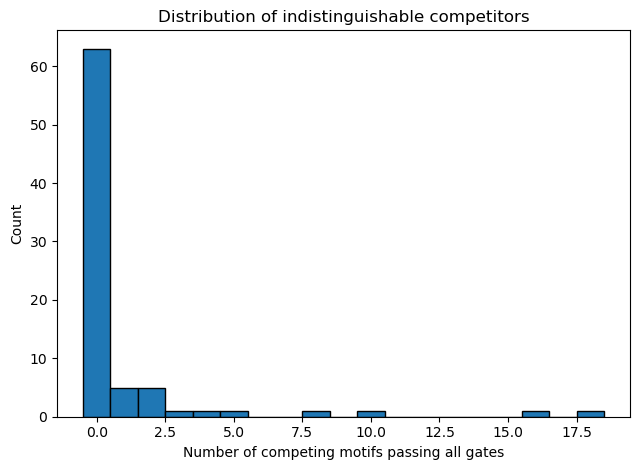

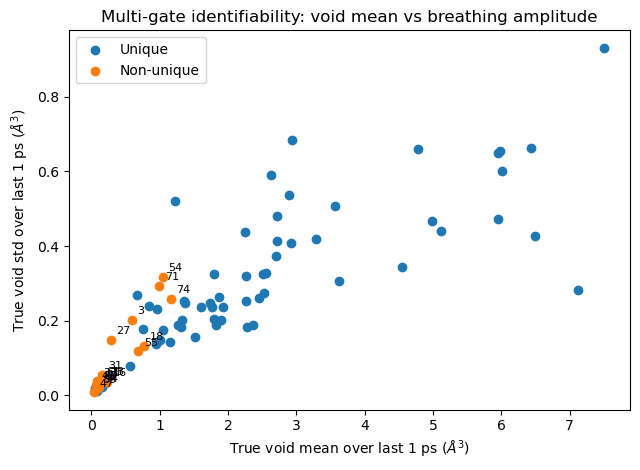

C:\Users\zilie\AppData\Local\Temp\ipykernel_16024\302846609.py:209: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
C:\Users\zilie\AppData\Local\Temp\ipykernel_16024\302846609.py:216: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


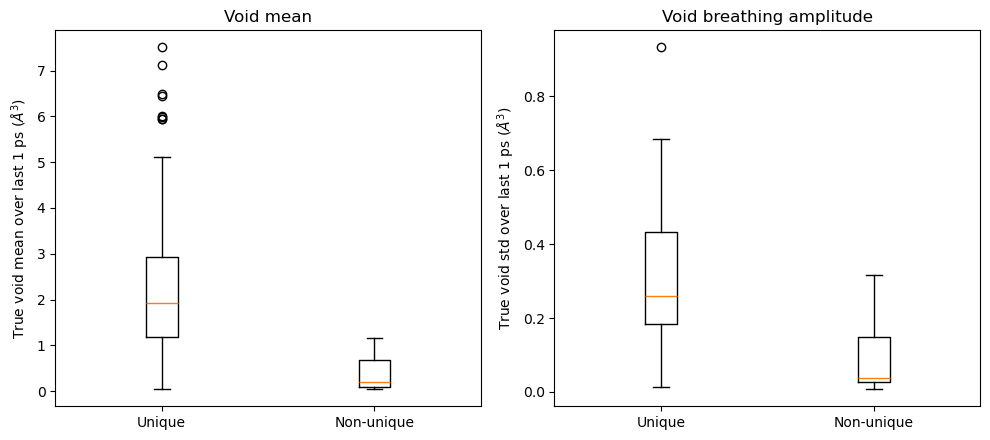


========== True void mean/std by event ==========

--- Unique ---
 event_id  void_mean_ref  void_std_ref
       40       0.048837      0.018971
       59       0.079444      0.012105
       19       0.083710      0.014488
       82       0.125001      0.024284
       42       0.155564      0.020463
       46       0.182218      0.028542
       35       0.274559      0.051205
       64       0.559230      0.077310
       38       0.664913      0.268147
       10       0.751787      0.178539
       45       0.848455      0.238341
        9       0.942631      0.135995
       93       0.964213      0.230184
       87       1.007755      0.149133
       34       1.048116      0.175444
       14       1.144457      0.141385
       20       1.229142      0.521940
       24       1.270773      0.186917
       49       1.313635      0.181730
       92       1.330264      0.201470
       85       1.353235      0.253105
       65       1.366512      0.247878
        6       1.519674      0.1559

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Input files
# ============================================================
summary_file = "stable_void_identifiability_summary_multigate_fast_last1ps.csv"
detail_file  = "stable_void_identifiability_candidates_multigate_fast_last1ps_long.csv"

df_sum = pd.read_csv(summary_file)
df_det = pd.read_csv(detail_file)

# ============================================================
# 1. Basic summary
# ============================================================
n_total = len(df_sum)
n_unique = int(df_sum["is_unique_all_gates"].sum())
n_nonunique = n_total - n_unique
frac_unique = n_unique / n_total if n_total > 0 else np.nan

print("========== Basic summary ==========")
print(f"Total stable-void events: {n_total}")
print(f"Unique events:            {n_unique}")
print(f"Non-unique events:        {n_nonunique}")
print(f"Unique fraction:          {frac_unique:.3f}")

# ============================================================
# 2. Which events are non-unique?
# ============================================================
df_nonunique = df_sum[df_sum["is_unique_all_gates"] == 0].copy()
df_nonunique = df_nonunique.sort_values(
    ["n_pass_other_all_gates", "void_mean_ref"],
    ascending=[False, True]
)

print("\n========== Non-unique events ==========")
if len(df_nonunique) == 0:
    print("None")
else:
    print(df_nonunique[[
        "event_id",
        "n_pass_other_all_gates",
        "void_mean_ref",
        "void_std_ref"
    ]].to_string(index=False))

df_nonunique.to_csv("nonunique_multigate_events.csv", index=False)

# ============================================================
# 3. Which events are unique?
# ============================================================
df_unique = df_sum[df_sum["is_unique_all_gates"] == 1].copy()
df_unique = df_unique.sort_values("void_mean_ref", ascending=True)

print("\n========== Unique events ==========")
if len(df_unique) == 0:
    print("None")
else:
    print(df_unique[[
        "event_id",
        "void_mean_ref",
        "void_std_ref"
    ]].to_string(index=False))

df_unique.to_csv("unique_multigate_events.csv", index=False)

# ============================================================
# 4. Group statistics: unique vs non-unique
# ============================================================
group_cols = [
    "void_mean_ref",
    "void_std_ref",
    "cn_mean_ref",
    "cn_std_ref",
    "n_pass_other_all_gates"
]

print("\n========== Group statistics ==========")
for gname, gdf in [
    ("unique", df_sum[df_sum["is_unique_all_gates"] == 1]),
    ("nonunique", df_sum[df_sum["is_unique_all_gates"] == 0])
]:
    print(f"\n--- {gname} ---")
    if len(gdf) == 0:
        print("No events")
        continue
    print(gdf[group_cols].agg(["mean", "std", "median", "min", "max"]))

# ============================================================
# 5. Save a compact table of true void mean/std for all events
# ============================================================
df_true_void = df_sum[[
    "event_id",
    "is_unique_all_gates",
    "void_mean_ref",
    "void_std_ref",
    "n_pass_other_all_gates"
]].copy()

df_true_void["label"] = np.where(df_true_void["is_unique_all_gates"] == 1, "Unique", "Non-unique")
df_true_void = df_true_void.sort_values(["is_unique_all_gates", "void_mean_ref"], ascending=[False, True])

df_true_void.to_csv("true_void_mean_std_all_events_multigate.csv", index=False)

print("\nSaved: true_void_mean_std_all_events_multigate.csv")

# ============================================================
# 6. For each non-unique event, inspect competitors that passed all gates
# ============================================================
rows = []

for eid in df_nonunique["event_id"].tolist():
    sub = df_det[df_det["event_id"] == eid].copy()

    sub_true = sub[sub["is_true_ovcore"] == 1]
    if len(sub_true) == 0:
        continue
    true_row = sub_true.iloc[0]

    sub_pass = sub[
        (sub["is_true_ovcore"] == 0) &
        (sub["passes_all_gates"] == 1)
    ].copy()

    for _, r in sub_pass.iterrows():
        rows.append({
            "event_id": eid,
            "true_triplet_ids": true_row["triplet_ids"],
            "candidate_triplet_ids": r["triplet_ids"],

            "true_void_final": true_row["void_final"],
            "candidate_void_final": r["void_final"],
            "abs_diff_void_final": abs(true_row["void_final"] - r["void_final"]),

            "true_cn_mean_final": true_row["cn_mean_final"],
            "candidate_cn_mean_final": r["cn_mean_final"],
            "abs_diff_cn_final": abs(true_row["cn_mean_final"] - r["cn_mean_final"]),

            "true_d1": true_row["d1_sorted_final"],
            "true_d2": true_row["d2_sorted_final"],
            "true_d3": true_row["d3_sorted_final"],

            "cand_d1": r["d1_sorted_final"],
            "cand_d2": r["d2_sorted_final"],
            "cand_d3": r["d3_sorted_final"],

            "pass_edges_gate": int(r["pass_edges_gate"]),
            "pass_cn_gate": int(r["pass_cn_gate"]),
            "pass_void_gate": int(r["pass_void_gate"]),
        })

df_passcomp = pd.DataFrame(rows)
df_passcomp.to_csv("passing_competitors_for_nonunique_events_multigate.csv", index=False)

print("\n========== Passing-competitor table saved ==========")
print("Saved: passing_competitors_for_nonunique_events_multigate.csv")

# ============================================================
# 7. Plot histogram of number of surviving competitors
# ============================================================
plt.figure(figsize=(6.5, 4.8))
plt.hist(
    df_sum["n_pass_other_all_gates"],
    bins=range(0, int(df_sum["n_pass_other_all_gates"].max()) + 2),
    align="left",
    edgecolor="black"
)
plt.xlabel("Number of competing motifs passing all gates")
plt.ylabel("Count")
plt.title("Distribution of indistinguishable competitors")
plt.tight_layout()
plt.savefig("multigate_pass_other_hist.png", dpi=300)
plt.show()

# ============================================================
# 8. Plot true void mean vs std, color by unique/non-unique
# ============================================================
plt.figure(figsize=(6.5, 4.8))

df_u = df_sum[df_sum["is_unique_all_gates"] == 1]
df_nu = df_sum[df_sum["is_unique_all_gates"] == 0]

plt.scatter(df_u["void_mean_ref"], df_u["void_std_ref"], label="Unique")
plt.scatter(df_nu["void_mean_ref"], df_nu["void_std_ref"], label="Non-unique")

for _, r in df_nu.iterrows():
    plt.annotate(
        str(int(r["event_id"])),
        (r["void_mean_ref"], r["void_std_ref"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel(r"True void mean over last 1 ps ($\AA^3$)")
plt.ylabel(r"True void std over last 1 ps ($\AA^3$)")
plt.title("Multi-gate identifiability: void mean vs breathing amplitude")
plt.legend()
plt.tight_layout()
plt.savefig("multigate_void_mean_vs_std_scatter.png", dpi=300)
plt.show()

# ============================================================
# 9. Boxplots for unique vs non-unique
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].boxplot(
    [df_u["void_mean_ref"].dropna(), df_nu["void_mean_ref"].dropna()],
    labels=["Unique", "Non-unique"]
)
axes[0].set_ylabel(r"True void mean over last 1 ps ($\AA^3$)")
axes[0].set_title("Void mean")

axes[1].boxplot(
    [df_u["void_std_ref"].dropna(), df_nu["void_std_ref"].dropna()],
    labels=["Unique", "Non-unique"]
)
axes[1].set_ylabel(r"True void std over last 1 ps ($\AA^3$)")
axes[1].set_title("Void breathing amplitude")

plt.tight_layout()
plt.savefig("multigate_void_boxplots_unique_vs_nonunique.png", dpi=300)
plt.show()

# ============================================================
# 10. Optional: print compact true void table in two groups
# ============================================================
print("\n========== True void mean/std by event ==========")
print("\n--- Unique ---")
if len(df_unique) == 0:
    print("None")
else:
    print(df_unique[["event_id", "void_mean_ref", "void_std_ref"]].to_string(index=False))

print("\n--- Non-unique ---")
if len(df_nonunique) == 0:
    print("None")
else:
    print(df_nonunique[["event_id", "void_mean_ref", "void_std_ref"]].to_string(index=False))